In [1]:
# ============================================================================
# CELL 1: Import Required Libraries
# ============================================================================
# Data manipulation and analysis
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)
from sklearn.feature_selection import SelectKBest, f_classif, RFE, mutual_info_classif

# Statistical analysis
from scipy import stats
from scipy.signal import find_peaks

# Model persistence
import joblib
import json
from datetime import datetime

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


✓ All libraries imported successfully!
NumPy version: 2.1.3
Pandas version: 2.2.3


In [2]:
# ============================================================================
# CELL 2
# ============================================================================
# Define project paths
BASE_DIR = os.path.dirname(os.getcwd())  # Parent directory
DATA_RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
DATA_NEW_DIR = os.path.join(BASE_DIR, 'data', 'new_data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
# Create subdirectories for figures
EDA_FIGURES_DIR = os.path.join(FIGURES_DIR, 'eda')
FEATURE_SEL_FIGURES_DIR = os.path.join(FIGURES_DIR, 'feature_selection')
MODEL_PERF_FIGURES_DIR = os.path.join(FIGURES_DIR, 'model_performance')
CONFUSION_MAT_DIR = os.path.join(MODEL_PERF_FIGURES_DIR, 'confusion_matrices')
ROC_CURVES_DIR = os.path.join(MODEL_PERF_FIGURES_DIR, 'roc_curves')
LEARNING_CURVES_DIR = os.path.join(MODEL_PERF_FIGURES_DIR, 'learning_curves')
INFERENCE_FIGURES_DIR = os.path.join(FIGURES_DIR, 'inference')
REPORTS_DIR = os.path.join(RESULTS_DIR, 'reports')
# Create all directories if they don't exist
for directory in [DATA_PROCESSED_DIR, MODELS_DIR, EDA_FIGURES_DIR, 
                  FEATURE_SEL_FIGURES_DIR, CONFUSION_MAT_DIR, ROC_CURVES_DIR,
                  LEARNING_CURVES_DIR, INFERENCE_FIGURES_DIR, REPORTS_DIR]:
    os.makedirs(directory, exist_ok=True)
# Configuration parameters
CONFIG = {
    'random_state': RANDOM_STATE,
    'test_size': 0.3,
    'cv_folds': 5,
    'n_top_features': 15,
    'figure_dpi': 300,
    'figure_size': (12, 8)
}
print("✓ Project structure initialized!")
print(f"Data directory: {DATA_RAW_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Results directory: {RESULTS_DIR}")
# Check if data files exist
csv_files = [f for f in os.listdir(DATA_RAW_DIR) if f.endswith('.csv')]
print(f"\n✓ Found {len(csv_files)} CSV files in data/raw/ directory")


✓ Project structure initialized!
Data directory: C:\Users\Satyajit\Desktop\Real-Time-TGT\data\raw
Models directory: C:\Users\Satyajit\Desktop\Real-Time-TGT\models
Results directory: C:\Users\Satyajit\Desktop\Real-Time-TGT\results

✓ Found 10 CSV files in data/raw/ directory


In [3]:
# ============================================================================
# CELL 3
# ============================================================================
def load_all_csv_files(data_dir):
    """
    Load all CSV files from the data directory and combine them.
    
    Parameters:
    -----------
    data_dir : str
        Path to directory containing CSV files
        
    Returns:
    --------
    combined_df : pandas DataFrame
        Combined dataframe with all data
    """
    all_dataframes = []
    csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])
    print(f"Loading {len(csv_files)} CSV files...")
    for idx, filename in enumerate(csv_files, 1):
        file_path = os.path.join(data_dir, filename)
        try:
            df = pd.read_csv(file_path)
            all_dataframes.append(df)
            print(f"  [{idx}/{len(csv_files)}] Loaded {filename}: {len(df)} rows, Class {df['classlabel'].unique()[0]}")
        except Exception as e:
            print(f"  [ERROR] Failed to load {filename}: {str(e)}")
    # Combine all dataframes
    combined_df = pd.concat(all_dataframes, ignore_index=True)
    print(f"\n✓ Successfully combined all data!")
    print(f"  Total rows: {len(combined_df)}")
    print(f"  Total features: {len(combined_df.columns)}")
    print(f"  Classes found: {sorted(combined_df['classlabel'].unique())}")
    return combined_df
# Load all data
df_raw = load_all_csv_files(DATA_RAW_DIR)
# Display first few rows
print("\nFirst 5 rows of combined data:")
print(df_raw.head())
# Save combined raw data
raw_data_path = os.path.join(DATA_PROCESSED_DIR, 'combined_raw_data.csv')
df_raw.to_csv(raw_data_path, index=False)
print(f"\n✓ Saved combined raw data to: {raw_data_path}")



Loading 10 CSV files...
  [1/10] Loaded airbus_a320_class2_1750rows_realistic.csv: 1750 rows, Class 2
  [2/10] Loaded apache_class9_2600rows_realistic.csv: 2600 rows, Class 9
  [3/10] Loaded boeing_747_class1_1650rows_realistic.csv: 1650 rows, Class 1
  [4/10] Loaded c17_class5_2950rows_realistic.csv: 2950 rows, Class 5
  [5/10] Loaded cessna172_class10_3150rows_realistic.csv: 3150 rows, Class 10
  [6/10] Loaded f22_class3_1850rows_realistic.csv: 1850 rows, Class 3
  [7/10] Loaded hal_tejas_class6_2550rows_realistic.csv: 2550 rows, Class 6
  [8/10] Loaded mq9_reaper_class8_2750rows_realistic.csv: 2750 rows, Class 8
  [9/10] Loaded rafale_class7_2350rows_realistic.csv: 2350 rows, Class 7
  [10/10] Loaded su30_class4_2850rows_realistic.csv: 2850 rows, Class 4

✓ Successfully combined all data!
  Total rows: 24450
  Total features: 6
  Classes found: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

First 5

In [4]:
# ============================================================================
# CELL 4
# ============================================================================
print("="*80)
print("INITIAL DATA EXPLORATION")
print("="*80)
# Basic information
print("\n1. DATASET INFORMATION:")
print("-" * 50)
print(f"Total Samples: {len(df_raw)}")
print(f"Total Features: {len(df_raw.columns)}")
print(f"Feature Names: {list(df_raw.columns)}")
print(f"Number of Classes: {df_raw['classlabel'].nunique()}")
print(f"Class Labels: {sorted(df_raw['classlabel'].unique())}")
# Data types
print("\n2. DATA TYPES:")
print("-" * 50)
print(df_raw.dtypes)
# Missing values
print("\n3. MISSING VALUES:")
print("-" * 50)
missing_values = df_raw.isnull().sum()
print(missing_values)
print(f"Total missing values: {missing_values.sum()}")
# Duplicate rows
print("\n4. DUPLICATE ROWS:")
print("-" * 50)
duplicates = df_raw.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
# Class distribution
print("\n5. CLASS DISTRIBUTION:")
print("-" * 50)
class_counts = df_raw['classlabel'].value_counts().sort_index()
print(class_counts)
print(f"\nClass balance ratio (min/max): {class_counts.min() / class_counts.max():.2f}")
# Statistical summary
print("\n6. STATISTICAL SUMMARY:")
print("-" * 50)
print(df_raw.describe())
# Save statistical summary
stats_summary = df_raw.describe()
stats_summary.to_csv(os.path.join(REPORTS_DIR, 'statistical_summary.csv'))
print(f"\n✓ Statistical summary saved to reports/")


INITIAL DATA EXPLORATION

1. DATASET INFORMATION:
--------------------------------------------------
Total Samples: 24450
Total Features: 6
Feature Names: ['Time', 'Height', 'Resultant_acceleration', 'Resultant_velocity', 'AGC', 'classlabel']
Number of Classes: 10
Class Labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

2. DATA TYPES:
--------------------------------------------------
Time                      float64
Height                    float64
Resultant_acceleration    float64
Resultant_velocity        float64
AGC                         int64
classlabel                  int64
dtype: object

3. MISSING VALUES:
--------------------------------------------------
Time                      0
Height                    0
Resultant_acceleration    0
Resultant_velocity        0
AGC                       0
classlabel                0
dtype: int64
Total missing values: 0

4. DUPLICATE ROWS:
--------

Generating EDA visualizations...


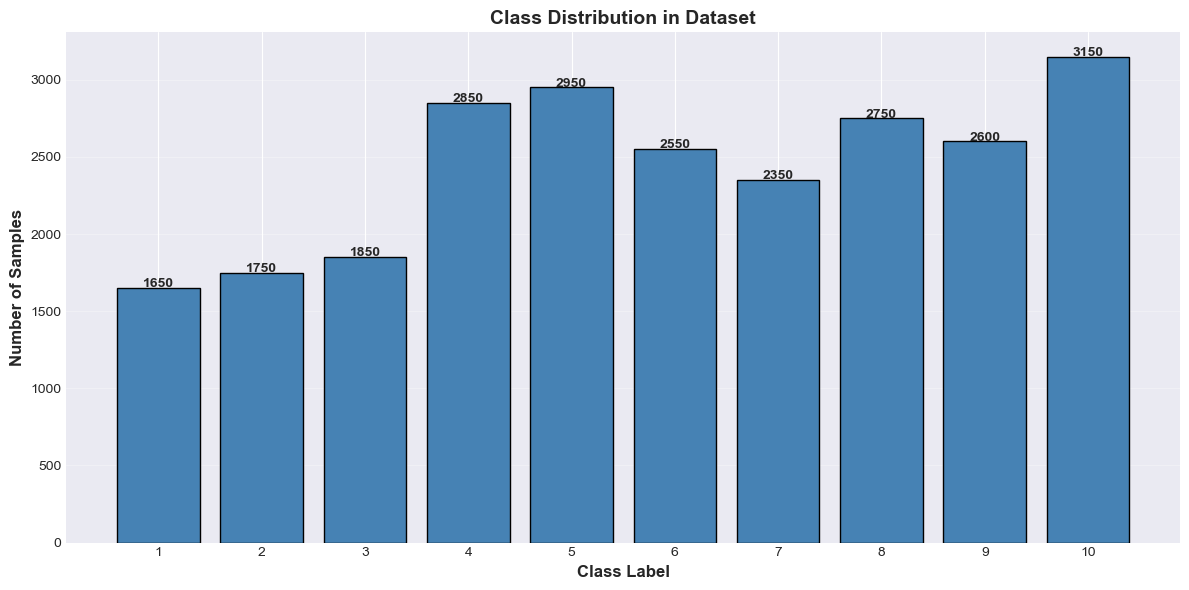

✓ Class distribution plot saved


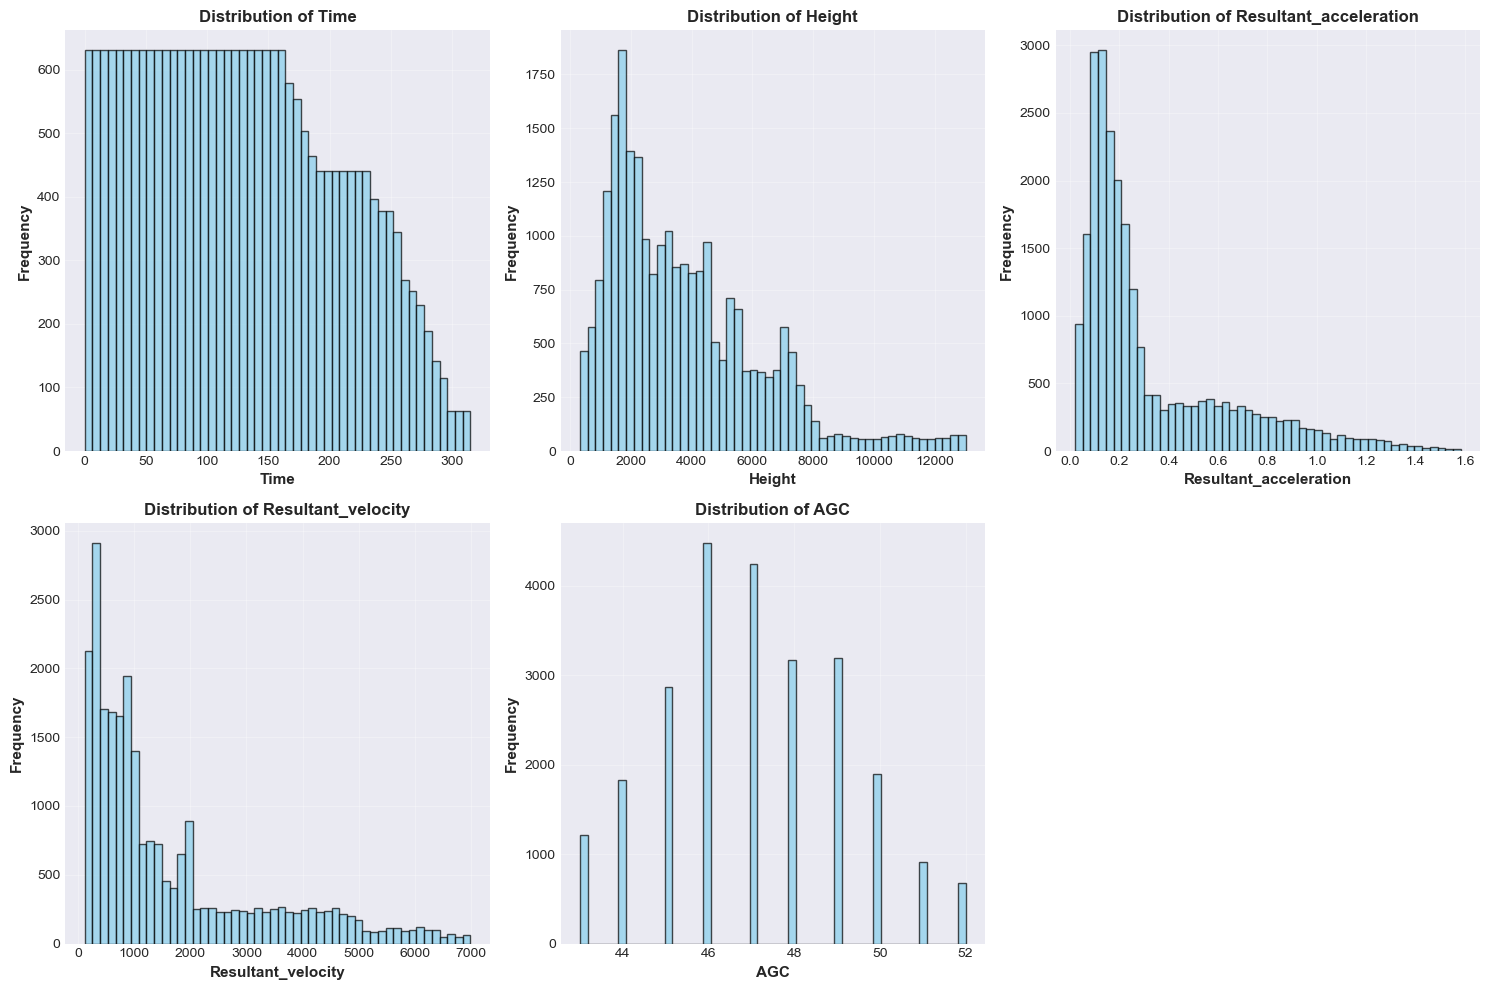

✓ Feature distributions plot saved


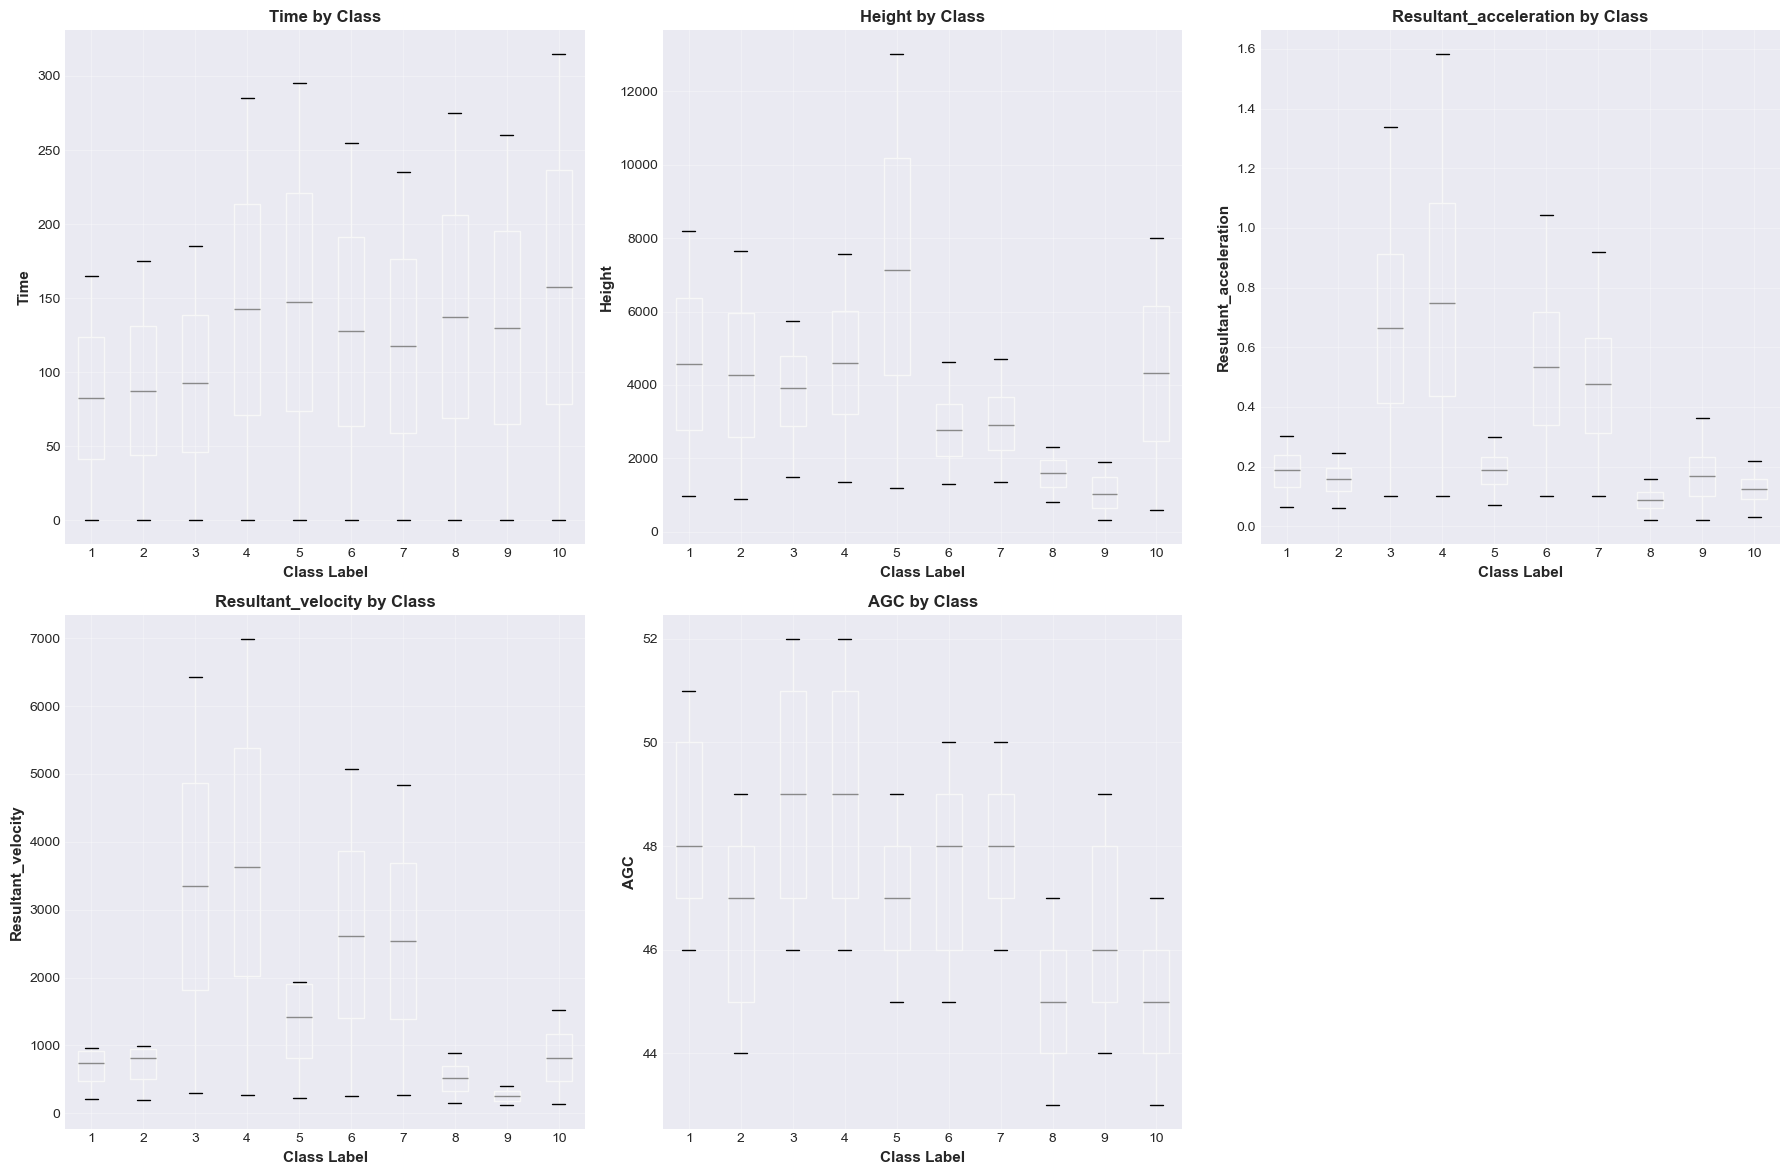

✓ Class-wise box plots saved


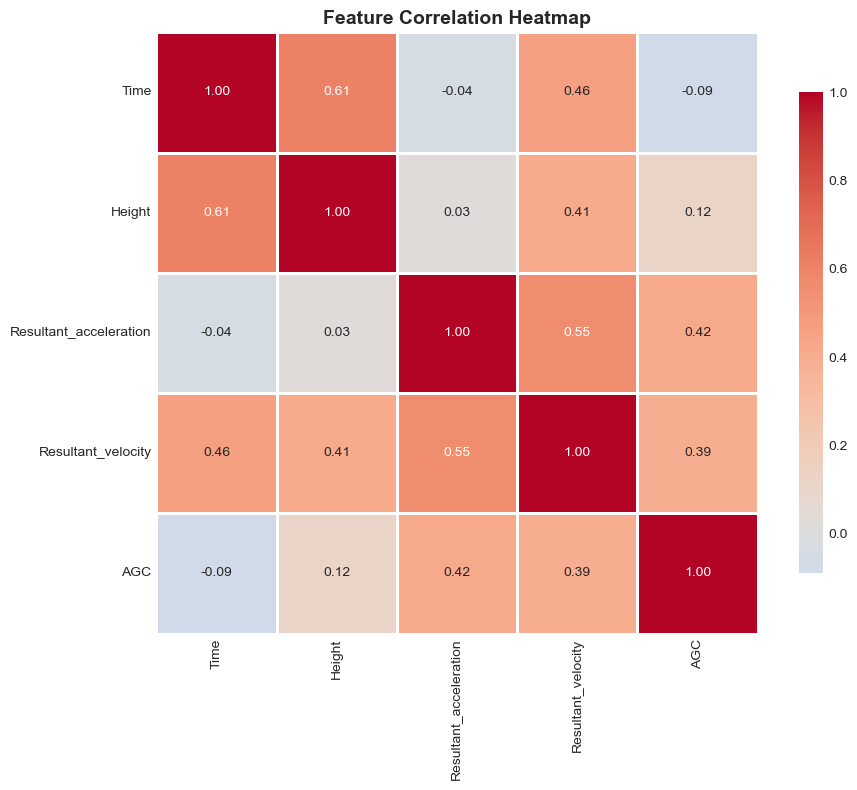

✓ Correlation heatmap saved

Generating pairplot (this may take a moment)...


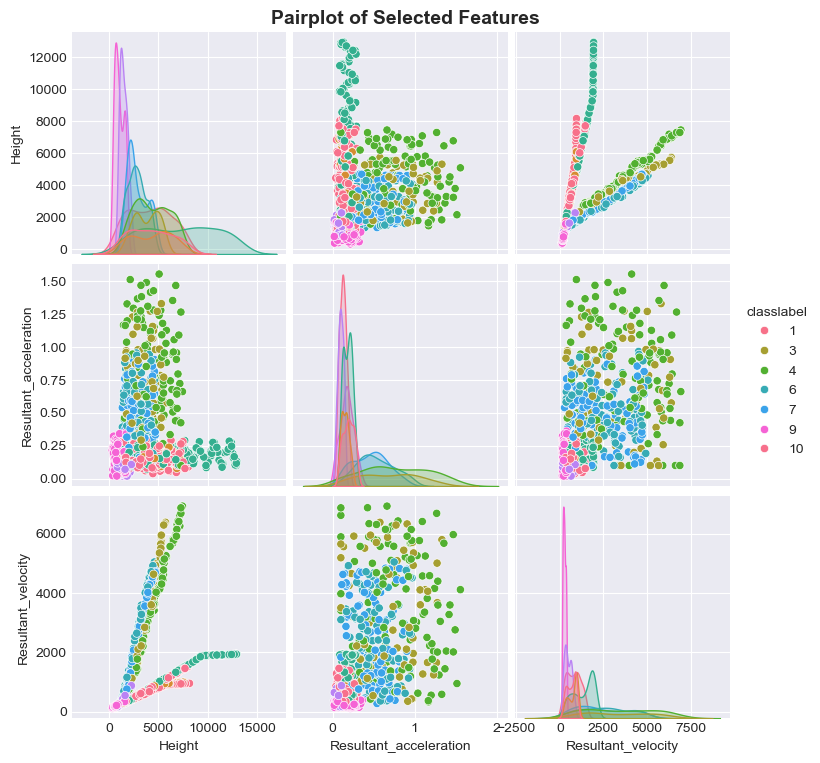

✓ Pairplot saved

✓ All EDA visualizations completed and saved!


In [5]:
# ============================================================================
# CELL 5
# ============================================================================
print("Generating EDA visualizations...")
# 1. Class Distribution Plot
plt.figure(figsize=(12, 6))
class_counts = df_raw['classlabel'].value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Class Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(class_counts.index)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts.values):
    plt.text(class_counts.index[i], v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURES_DIR, 'class_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Class distribution plot saved")
# 2. Feature Distributions (Histograms)
features = ['Time', 'Height', 'Resultant_acceleration', 'Resultant_velocity', 'AGC']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for idx, feature in enumerate(features):
    axes[idx].hist(df_raw[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
# Remove empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURES_DIR, 'feature_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Feature distributions plot saved")
# 3. Box Plots for Each Feature by Class
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
for idx, feature in enumerate(features):
    df_raw.boxplot(column=feature, by='classlabel', ax=axes[idx])
    axes[idx].set_xlabel('Class Label', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} by Class', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
fig.delaxes(axes[5])
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURES_DIR, 'class_wise_boxplots.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Class-wise box plots saved")
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_raw[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURES_DIR, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Correlation heatmap saved")
# 5. Pairplot for top 3 features (sample)
print("\nGenerating pairplot (this may take a moment)...")
sample_features = ['Height', 'Resultant_acceleration', 'Resultant_velocity', 'classlabel']
sample_df = df_raw[sample_features].sample(n=min(1000, len(df_raw)), random_state=RANDOM_STATE)
pairplot = sns.pairplot(sample_df, hue='classlabel', diag_kind='kde', palette='husl')
pairplot.fig.suptitle('Pairplot of Selected Features', y=1.01, fontsize=14, fontweight='bold')
plt.savefig(os.path.join(EDA_FIGURES_DIR, 'feature_pairplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Pairplot saved")
print("\n✓ All EDA visualizations completed and saved!")


In [6]:
# ============================================================================
# CELL 6
# ============================================================================
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)
def extract_time_series_features(df):
    """
    Extract statistical and temporal features from time-series kinematics data.
    
    Features extracted per trajectory (grouped by some identifier):
    - Statistical: mean, std, min, max, range, median, variance, skewness, kurtosis
    - Temporal: rate of change, derivatives, autocorrelation
    - Domain-specific: ratios, energy, trajectory characteristics
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with kinematics data
        
    Returns:
    --------
    feature_df : pandas DataFrame
        Dataframe with extracted features
    """
    
    print("\nExtracting features from time-series data...")
    # Group by class to extract features per trajectory
    # Assuming each class file represents one trajectory
    # We'll create a trajectory ID based on class and time windows
    features_list = []
    # Group data by class label (each CSV is one trajectory)
    grouped = df.groupby('classlabel')
    for class_label, group_data in grouped:
        feature_dict = {'classlabel': class_label}
        
        # Original features
        height = group_data['Height'].values
        accel = group_data['Resultant_acceleration'].values
        velocity = group_data['Resultant_velocity'].values
        agc = group_data['AGC'].values
        time = group_data['Time'].values
        # ===== STATISTICAL FEATURES =====
        # Height features
        feature_dict['height_mean'] = np.mean(height)
        feature_dict['height_std'] = np.std(height)
        feature_dict['height_min'] = np.min(height)
        feature_dict['height_max'] = np.max(height)
        feature_dict['height_range'] = np.max(height) - np.min(height)
        feature_dict['height_median'] = np.median(height)
        feature_dict['height_variance'] = np.var(height)
        feature_dict['height_skewness'] = stats.skew(height)
        feature_dict['height_kurtosis'] = stats.kurtosis(height)
        feature_dict['height_q25'] = np.percentile(height, 25)
        feature_dict['height_q75'] = np.percentile(height, 75)
        # Acceleration features
        feature_dict['accel_mean'] = np.mean(accel)
        feature_dict['accel_std'] = np.std(accel)
        feature_dict['accel_min'] = np.min(accel)
        feature_dict['accel_max'] = np.max(accel)
        feature_dict['accel_range'] = np.max(accel) - np.min(accel)
        feature_dict['accel_median'] = np.median(accel)
        feature_dict['accel_variance'] = np.var(accel)
        feature_dict['accel_skewness'] = stats.skew(accel)
        feature_dict['accel_kurtosis'] = stats.kurtosis(accel)
        # Velocity features
        feature_dict['velocity_mean'] = np.mean(velocity)
        feature_dict['velocity_std'] = np.std(velocity)
        feature_dict['velocity_min'] = np.min(velocity)
        feature_dict['velocity_max'] = np.max(velocity)
        feature_dict['velocity_range'] = np.max(velocity) - np.min(velocity)
        feature_dict['velocity_median'] = np.median(velocity)
        feature_dict['velocity_variance'] = np.var(velocity)
        feature_dict['velocity_skewness'] = stats.skew(velocity)
        feature_dict['velocity_kurtosis'] = stats.kurtosis(velocity)
        # AGC features
        feature_dict['agc_mean'] = np.mean(agc)
        feature_dict['agc_std'] = np.std(agc)
        feature_dict['agc_min'] = np.min(agc)
        feature_dict['agc_max'] = np.max(agc)
        feature_dict['agc_range'] = np.max(agc) - np.min(agc)
        # ===== TEMPORAL FEATURES =====
        # Rate of change (derivatives)
        if len(height) > 1:
            height_rate = np.diff(height) / np.diff(time)
            accel_rate = np.diff(accel) / np.diff(time)
            velocity_rate = np.diff(velocity) / np.diff(time)
            feature_dict['height_rate_mean'] = np.mean(height_rate)
            feature_dict['height_rate_std'] = np.std(height_rate)
            feature_dict['accel_rate_mean'] = np.mean(accel_rate)
            feature_dict['accel_rate_std'] = np.std(accel_rate)
            feature_dict['velocity_rate_mean'] = np.mean(velocity_rate)
            feature_dict['velocity_rate_std'] = np.std(velocity_rate)
        # Autocorrelation at lag 1
        if len(accel) > 1:
            feature_dict['accel_autocorr_lag1'] = np.corrcoef(accel[:-1], accel[1:])[0, 1]
            feature_dict['velocity_autocorr_lag1'] = np.corrcoef(velocity[:-1], velocity[1:])[0, 1]
        # ===== DOMAIN-SPECIFIC FEATURES =====
        # Ratios
        feature_dict['height_velocity_ratio'] = np.mean(height) / (np.mean(velocity) + 1e-10)
        feature_dict['accel_velocity_ratio'] = np.mean(accel) / (np.mean(velocity) + 1e-10)
        # Energy and power
        feature_dict['accel_energy'] = np.sum(accel**2)
        feature_dict['velocity_energy'] = np.sum(velocity**2)
        # Trajectory duration
        feature_dict['trajectory_duration'] = time[-1] - time[0] if len(time) > 0 else 0
        # Number of peaks in acceleration
        peaks, _ = find_peaks(accel)
        feature_dict['accel_num_peaks'] = len(peaks)
        features_list.append(feature_dict)
    # Create DataFrame
    feature_df = pd.DataFrame(features_list)
    print(f"\n✓ Feature extraction complete!")
    print(f"  Original features: 5")
    print(f"  Extracted features: {len(feature_df.columns) - 1}")  # Exclude classlabel
    print(f"  Total samples: {len(feature_df)}")
    return feature_df
# Extract features
df_features = extract_time_series_features(df_raw)
# Display extracted features
print("\nExtracted Features (first 5 rows):")
print(df_features.head())
# Save extracted features
features_path = os.path.join(DATA_PROCESSED_DIR, 'extracted_features.csv')
df_features.to_csv(features_path, index=False)
print(f"\n✓ Extracted features saved to: {features_path}")

FEATURE ENGINEERING

Extracting features from time-series data...

✓ Feature extraction complete!
  Original features: 5
  Extracted features: 48
  Total samples: 10

Extracted Features (first 5 rows):
   classlabel  height_mean   height_std  height_min  height_max  height_range  \
0           1  4595.503812  2053.838951      984.68     8195.08       7210.40   
1           2  4316.092046  1947.174725      904.20     7649.69       6745.49   
2           3  3845.984541  1171.818370     1486.32     5739.78       4253.46   
3           4  4578.355060  1730.281558     1369.15     7568.58       6199.43   
4           5  7171.009085  3407.402407     1204.92    13019.06      11814.14   

   height_median  height_variance  height_skewness  height_kurtosis  ...  \
0       4572.325     4.218254e+06        -0.000363        -1.193039  ...   
1       4280.305     3.791489e+06        -0.005986        -1.193670  ...   
2       3916.640     1.373158e+06        -0.263971        -1.089139  ...   
3      

In [7]:
"""
Alternative approach: Extract features using sliding windows on raw data
This creates more samples by treating each window as a separate instance
"""
# ============================================================================
# CELL 7
# ============================================================================
def extract_window_based_features(df, window_size=50, step_size=25):
    """
    Extract features using sliding windows on time-series data.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time-series data
    window_size : int
        Number of time steps in each window
    step_size : int
        Number of steps to slide the window
        
    Returns:
    --------
    feature_df : pandas DataFrame
        Dataframe with extracted features per window
    """
    
    print(f"\nExtracting window-based features (window={window_size}, step={step_size})...")
    
    features_list = []
    # Group by class
    grouped = df.groupby('classlabel')
    for class_label, group_data in grouped:
        group_data = group_data.reset_index(drop=True)
        
        # Slide window through the data
        for start_idx in range(0, len(group_data) - window_size + 1, step_size):
            end_idx = start_idx + window_size
            window = group_data.iloc[start_idx:end_idx]
            
            feature_dict = {'classlabel': class_label}
            
            # Extract features from window
            for col in ['Height', 'Resultant_acceleration', 'Resultant_velocity', 'AGC']:
                values = window[col].values
                
                feature_dict[f'{col}_mean'] = np.mean(values)
                feature_dict[f'{col}_std'] = np.std(values)
                feature_dict[f'{col}_min'] = np.min(values)
                feature_dict[f'{col}_max'] = np.max(values)
                feature_dict[f'{col}_median'] = np.median(values)
                feature_dict[f'{col}_range'] = np.max(values) - np.min(values)
                
                # Rate of change
                if len(values) > 1:
                    rate = np.diff(values)
                    feature_dict[f'{col}_rate_mean'] = np.mean(rate)
                    feature_dict[f'{col}_rate_std'] = np.std(rate)
            
            features_list.append(feature_dict)
    
    feature_df = pd.DataFrame(features_list)
    
    print(f"✓ Window-based feature extraction complete!")
    print(f"  Total windows/samples: {len(feature_df)}")
    print(f"  Features per window: {len(feature_df.columns) - 1}")
    return feature_df
# Extract window-based features (this creates more samples)
df_features_windowed = extract_window_based_features(df_raw, window_size=50, step_size=25)
print("\nWindow-based Features (first 5 rows):")
print(df_features_windowed.head())
# Save windowed features
windowed_features_path = os.path.join(DATA_PROCESSED_DIR, 'windowed_features.csv')
df_features_windowed.to_csv(windowed_features_path, index=False)
print(f"\n✓ Windowed features saved to: {windowed_features_path}")
# Choose which feature set to use
print("\n" + "="*80)
print("CHOOSING FEATURE SET")
print("="*80)
print("\nOption 1: Class-level features (one sample per class)")
print(f"  Samples: {len(df_features)}, Features: {len(df_features.columns) - 1}")
print("\nOption 2: Window-based features (multiple samples per class)")
print(f"  Samples: {len(df_features_windowed)}, Features: {len(df_features_windowed.columns) - 1}")
# Use window-based features for better training (more samples)
df_final_features = df_features_windowed.copy()
print(f"\n✓ Selected: Window-based features with {len(df_final_features)} samples")




Extracting window-based features (window=50, step=25)...
✓ Window-based feature extraction complete!
  Total windows/samples: 968
  Features per window: 32

Window-based Features (first 5 rows):
   classlabel  Height_mean  Height_std  Height_min  Height_max  Height_median  \
0           1    1096.6438   68.291919      984.68     1214.37       1092.670   
1           1    1218.7254   72.222229     1095.31     1342.40       1216.995   
2           1    1345.7848   74.731908     1219.62     1474.68       1345.485   
3           1    1474.1518   74.106308     1348.57     1599.24       1476.800   
4           1    1602.0330   73.663778     1478.92     1723.95       1601.915   

   Height_range  Height_rate_mean  Height_rate_std  \
0        229.69          4.687551         0.960061   
1        247.09          5.042653         0.891556   
2        255.06          5.205306         0.865347   
3        250.67          5.115714         0.820761   
4        245.03          5.000612         0.843

In [8]:
# ============================================================================
# CELL 8
# ============================================================================
print("="*80)
print("DATA PREPARATION FOR MACHINE LEARNING")
print("="*80)
# Separate features and target
X = df_final_features.drop('classlabel', axis=1)
y = df_final_features['classlabel']
print(f"\n1. Dataset Shape:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"   Number of classes: {y.nunique()}")
print(f"   Class distribution:\n{y.value_counts().sort_index()}")
# Check for missing values
print(f"\n2. Missing Values:")
print(f"   Features: {X.isnull().sum().sum()}")
print(f"   Target: {y.isnull().sum()}")
# Handle any missing values (if present)
if X.isnull().sum().sum() > 0:
    print("\n   Filling missing values with median...")
    X = X.fillna(X.median())
# Check for infinite values
print(f"\n3. Infinite Values:")
inf_count = np.isinf(X).sum().sum()
print(f"   Features: {inf_count}")
if inf_count > 0:
    print("   Replacing infinite values with large finite numbers...")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
# Feature names
feature_names = X.columns.tolist()
print(f"\n4. Feature Names ({len(feature_names)} features):")
for i, name in enumerate(feature_names, 1):
    print(f"   {i:2d}. {name}")
# Class distribution check
print(f"\n5. Class Balance Analysis:")
class_counts = y.value_counts().sort_index()
balance_ratio = class_counts.min() / class_counts.max()
print(f"   Min samples: {class_counts.min()}")
print(f"   Max samples: {class_counts.max()}")
print(f"   Balance ratio: {balance_ratio:.3f}")
if balance_ratio < 0.5:
    print("   ⚠ Dataset is imbalanced (consider using class weights or SMOTE)")
else:
    print("   ✓ Dataset is reasonably balanced")
print("\n✓ Data preparation complete!")

DATA PREPARATION FOR MACHINE LEARNING

1. Dataset Shape:
   Features (X): (968, 32)
   Target (y): (968,)
   Number of classes: 10
   Class distribution:
classlabel
1      65
2      69
3      73
4     113
5     117
6     101
7      93
8     109
9     103
10    125
Name: count, dtype: int64

2. Missing Values:
   Features: 0
   Target: 0

3. Infinite Values:
   Features: 0

4. Feature Names (32 features):
    1. Height_mean
    2. Height_std
    3. Height_min
    4. Height_max
    5. Height_median
    6. Height_range
    7. Height_rate_mean
    8. Height_rate_std
    9. Resultant_acceleration_mean
   10. Resultant_acceleration_std
   11. Resultant_acceleration_min
   12. Resultant_acceleration_max
   13. Resultant_acceleration_median
   14. Resultant_acceleration_range
   15. Resultant_acceleration_rate_mean
   16. Resultant_acceleration_rate_std
   17. Resultant_velocity_mean
   18. Resultant_velocity_std
   19. Resultant_velocity_min
   20. Resultant_velocity_max
   21. Resultant_velo

FEATURE SCALING

✓ Features scaled using StandardScaler (Z-score normalization)

Scaled data statistics:
        Height_mean    Height_std    Height_min    Height_max  Height_median  \
count  9.680000e+02  9.680000e+02  9.680000e+02  9.680000e+02   9.680000e+02   
mean  -2.055289e-16  1.761676e-16 -2.055289e-16  2.055289e-16   1.761676e-16   
std    1.000517e+00  1.000517e+00  1.000517e+00  1.000517e+00   1.000517e+00   
min   -1.360739e+00 -1.501593e+00 -1.359984e+00 -1.360024e+00  -1.363439e+00   
25%   -7.803021e-01 -7.965652e-01 -7.807079e-01 -7.826091e-01  -7.788961e-01   
50%   -2.149482e-01  2.301087e-02 -2.293235e-01 -2.089907e-01  -2.149254e-01   
75%    5.674303e-01  6.534259e-01  5.743946e-01  5.705263e-01   5.666833e-01   
max    3.697650e+00  4.685674e+00  3.718999e+00  3.674620e+00   3.698864e+00   

       Height_range  Height_rate_mean  Height_rate_std  \
count    968.000000      9.680000e+02     9.680000e+02   
mean       0.000000     -8.808381e-17     2.936127e-17   


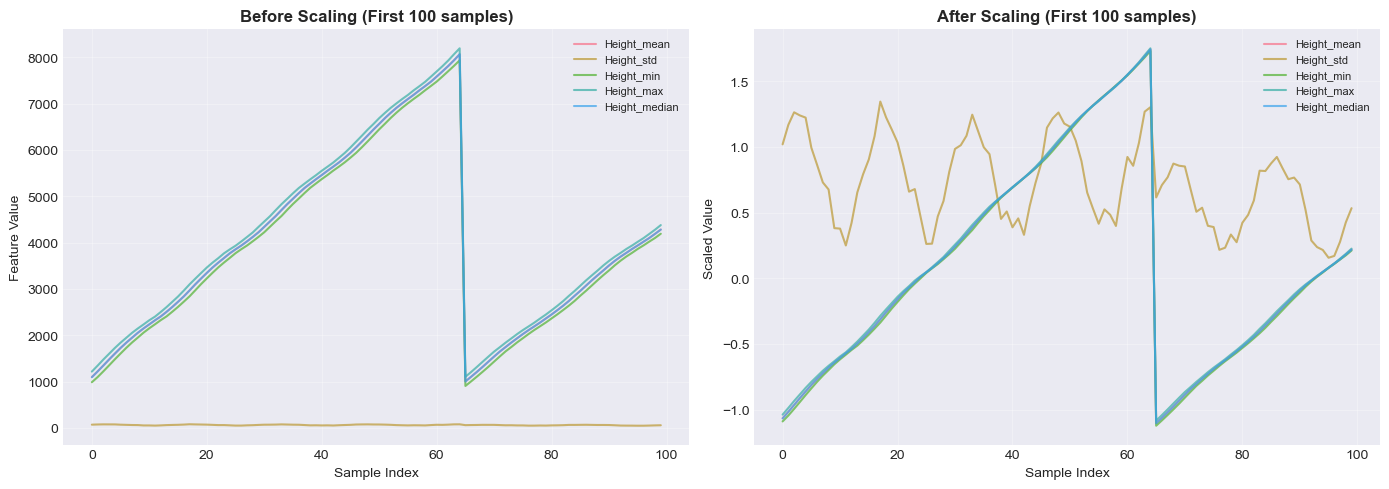


✓ Scaling visualization saved
✓ Scaler saved to: C:\Users\Satyajit\Desktop\Real-Time-TGT\models\scaler.pkl


In [9]:
# ============================================================================
# CELL 9
# ============================================================================
print("="*80)
print("FEATURE SCALING")
print("="*80)
# Initialize scaler
scaler = StandardScaler()
# Fit and transform features
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)
print(f"\n✓ Features scaled using StandardScaler (Z-score normalization)")
print(f"\nScaled data statistics:")
print(X_scaled.describe())
# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Before scaling (first 5 features)
sample_features = feature_names[:5]
X[sample_features].iloc[:100].plot(ax=axes[0], alpha=0.7)
axes[0].set_title('Before Scaling (First 100 samples)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Feature Value')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(alpha=0.3)
# After scaling
X_scaled[sample_features].iloc[:100].plot(ax=axes[1], alpha=0.7)
axes[1].set_title('After Scaling (First 100 samples)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Scaled Value')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'scaling_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Scaling visualization saved")
# Save scaler for future use
scaler_path = os.path.join(MODELS_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")



TRAIN-TEST SPLIT

✓ Data split completed!

1. Training Set:
   Samples: 677 (69.9%)
   Features: 32
   Class distribution:
classlabel
1     46
2     48
3     51
4     79
5     82
6     71
7     65
8     76
9     72
10    87
Name: count, dtype: int64

2. Test Set:
   Samples: 291 (30.1%)
   Features: 32
   Class distribution:
classlabel
1     19
2     21
3     22
4     34
5     35
6     30
7     28
8     33
9     31
10    38
Name: count, dtype: int64


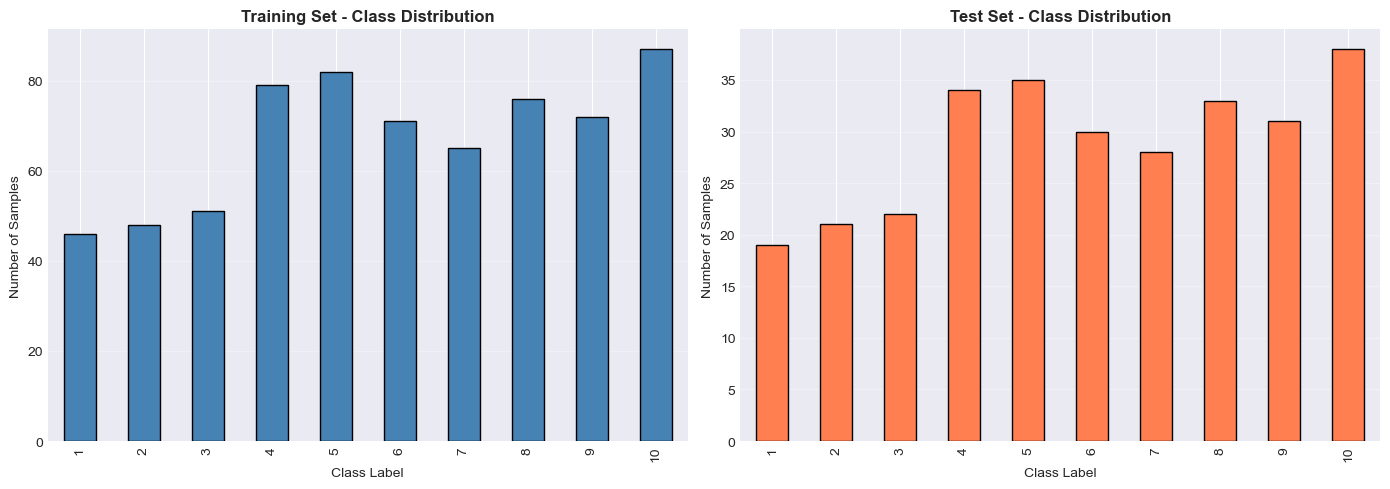


✓ Train-test split visualization saved


In [10]:
# ============================================================================
# CELL 10
# ============================================================================
print("="*80)
print("TRAIN-TEST SPLIT")
print("="*80)
# Split data (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=CONFIG['test_size'], 
    random_state=CONFIG['random_state'],
    stratify=y
)
print(f"\n✓ Data split completed!")
print(f"\n1. Training Set:")
print(f"   Samples: {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"   Features: {X_train.shape[1]}")
print(f"   Class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\n2. Test Set:")
print(f"   Samples: {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)")
print(f"   Features: {X_test.shape[1]}")
print(f"   Class distribution:\n{y_test.value_counts().sort_index()}")
# Visualize train-test split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Training set class distribution
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Set - Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(axis='y', alpha=0.3)
# Test set class distribution
y_test.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Test Set - Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class Label')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'train_test_split.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Train-test split visualization saved")



FEATURE SELECTION - STATISTICAL METHODS

1. ANOVA F-test for Feature Selection
--------------------------------------------------

Top 15 features by ANOVA F-test:
                            Feature       F_Score        P_Value
26                          AGC_min  8.814769e+16   0.000000e+00
27                          AGC_max  3.672251e+16   0.000000e+00
7                   Height_rate_std  7.953067e+03   0.000000e+00
15  Resultant_acceleration_rate_std  2.934967e+03   0.000000e+00
24                         AGC_mean  2.600126e+03   0.000000e+00
23      Resultant_velocity_rate_std  1.515146e+03   0.000000e+00
21         Resultant_velocity_range  1.280763e+03   0.000000e+00
22     Resultant_velocity_rate_mean  1.202372e+03   0.000000e+00
13     Resultant_acceleration_range  1.134872e+03   0.000000e+00
17           Resultant_velocity_std  1.126668e+03   0.000000e+00
9        Resultant_acceleration_std  1.113371e+03   0.000000e+00
11       Resultant_acceleration_max  9.389364e+02   0.00

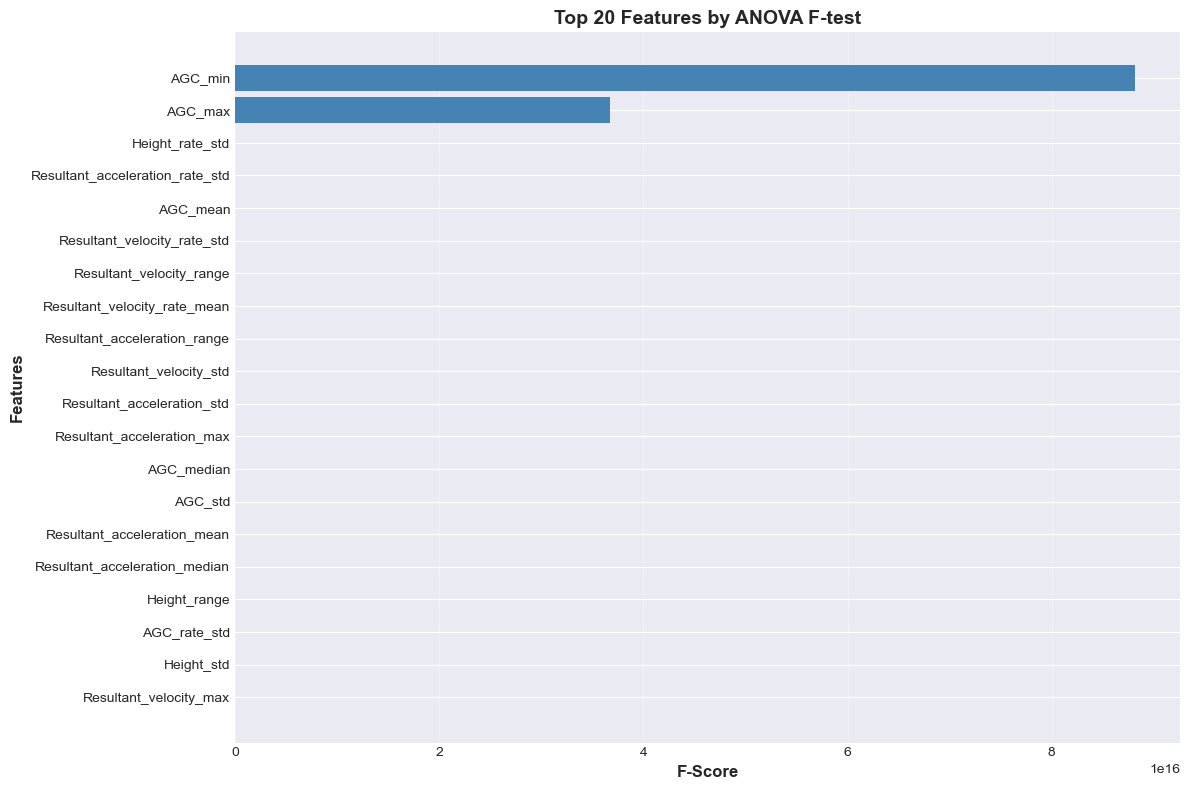


2. Mutual Information for Feature Selection
--------------------------------------------------

Top 15 features by Mutual Information:
                            Feature  MI_Score
7                   Height_rate_std  1.940395
22     Resultant_velocity_rate_mean  1.729778
21         Resultant_velocity_range  1.699817
17           Resultant_velocity_std  1.656422
27                          AGC_max  1.547228
15  Resultant_acceleration_rate_std  1.539761
9        Resultant_acceleration_std  1.520473
24                         AGC_mean  1.518032
23      Resultant_velocity_rate_std  1.497691
11       Resultant_acceleration_max  1.491574
13     Resultant_acceleration_range  1.477412
26                          AGC_min  1.336975
8       Resultant_acceleration_mean  1.093830
29                        AGC_range  1.019085
28                       AGC_median  1.016917


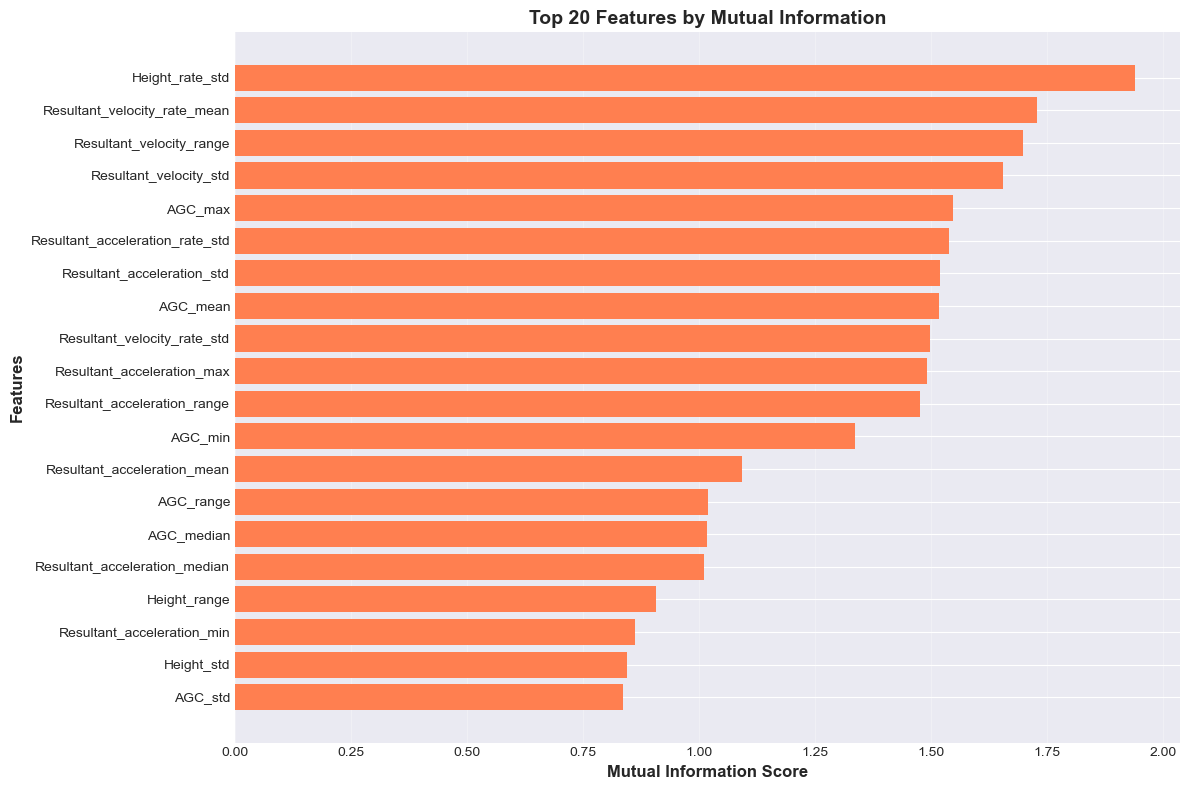


✓ Statistical feature selection completed


In [11]:
# ============================================================================
# CELL 11
# ============================================================================
print("="*80)
print("FEATURE SELECTION - STATISTICAL METHODS")
print("="*80)
# Method 1: ANOVA F-test
print("\n1. ANOVA F-test for Feature Selection")
print("-" * 50)
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_train, y_train)
# Get scores
anova_scores = pd.DataFrame({
    'Feature': feature_names,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)
print("\nTop 15 features by ANOVA F-test:")
print(anova_scores.head(15))
# Visualize ANOVA scores
plt.figure(figsize=(12, 8))
top_features_anova = anova_scores.head(20)
plt.barh(range(len(top_features_anova)), top_features_anova['F_Score'], color='steelblue')
plt.yticks(range(len(top_features_anova)), top_features_anova['Feature'])
plt.xlabel('F-Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by ANOVA F-test', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'anova_feature_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
# Method 2: Mutual Information
print("\n2. Mutual Information for Feature Selection")
print("-" * 50)
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_scores_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)
print("\nTop 15 features by Mutual Information:")
print(mi_scores_df.head(15))
# Visualize MI scores
plt.figure(figsize=(12, 8))
top_features_mi = mi_scores_df.head(20)
plt.barh(range(len(top_features_mi)), top_features_mi['MI_Score'], color='coral')
plt.yticks(range(len(top_features_mi)), top_features_mi['Feature'])
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by Mutual Information', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'mutual_information_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Statistical feature selection completed")

FEATURE SELECTION - MODEL-BASED METHODS

3. Random Forest Feature Importance
--------------------------------------------------

Top 15 features by Random Forest:
                            Feature  Importance
7                   Height_rate_std    0.108307
26                          AGC_min    0.085958
24                         AGC_mean    0.079343
29                        AGC_range    0.079170
27                          AGC_max    0.078780
15  Resultant_acceleration_rate_std    0.055686
22     Resultant_velocity_rate_mean    0.050436
13     Resultant_acceleration_range    0.048850
21         Resultant_velocity_range    0.045433
23      Resultant_velocity_rate_std    0.045244
9        Resultant_acceleration_std    0.044131
17           Resultant_velocity_std    0.043741
1                        Height_std    0.035503
5                      Height_range    0.033171
25                          AGC_std    0.032049


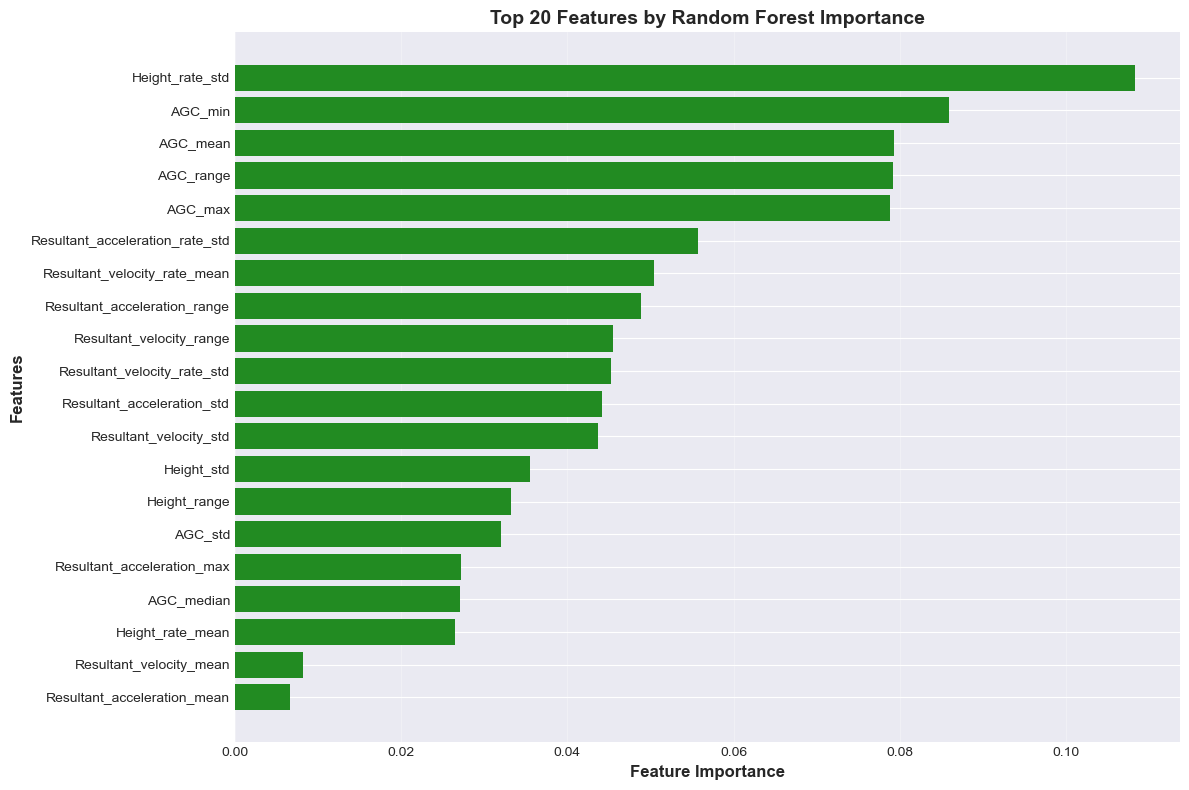


4. XGBoost Feature Importance
--------------------------------------------------

Top 15 features by XGBoost:
                            Feature  Importance
13     Resultant_acceleration_range    0.156591
0                       Height_mean    0.137284
19           Resultant_velocity_max    0.091529
27                          AGC_max    0.088873
26                          AGC_min    0.081553
7                   Height_rate_std    0.080133
21         Resultant_velocity_range    0.077260
29                        AGC_range    0.074954
6                  Height_rate_mean    0.050695
1                        Height_std    0.046717
15  Resultant_acceleration_rate_std    0.031147
17           Resultant_velocity_std    0.023832
23      Resultant_velocity_rate_std    0.011667
30                    AGC_rate_mean    0.008544
24                         AGC_mean    0.007616


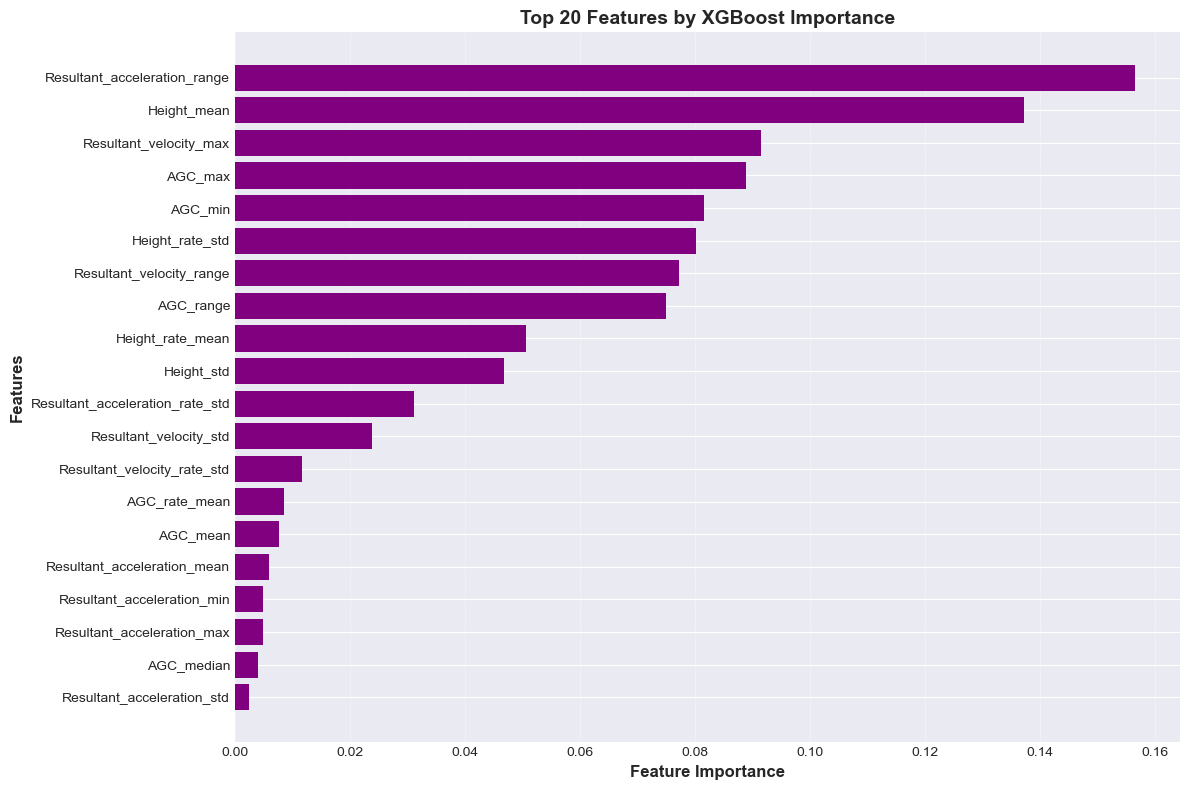


✓ Model-based feature selection completed


In [12]:
# ============================================================================
# CELL 12
# ============================================================================
print("="*80)
print("FEATURE SELECTION - MODEL-BASED METHODS")
print("="*80)
# Method 3: Random Forest Feature Importance
print("\n3. Random Forest Feature Importance")
print("-" * 50)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X_train, y_train)
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 15 features by Random Forest:")
print(rf_importance.head(15))
# Visualize RF importance
plt.figure(figsize=(12, 8))
top_features_rf = rf_importance.head(20)
plt.barh(range(len(top_features_rf)), top_features_rf['Importance'], color='forestgreen')
plt.yticks(range(len(top_features_rf)), top_features_rf['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'random_forest_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
# Method 4: XGBoost Feature Importance
# print("\n4. XGBoost Feature Importance")
# print("-" * 50)
# xgb_selector = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss')
# xgb_selector.fit(X_train, y_train)
# xgb_importance = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': xgb_selector.feature_importances_
# }).sort_values('Importance', ascending=False)
# print("\nTop 15 features by XGBoost:")
# print(xgb_importance.head(15))
# Method 4: XGBoost Feature Importance
print("\n4. XGBoost Feature Importance")
print("-" * 50)
# Convert labels from 1-10 to 0-9 for XGBoost
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1  # If you'll use this later
xgb_selector = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, eval_metric='mlogloss')
xgb_selector.fit(X_train, y_train_xgb)
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_selector.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 15 features by XGBoost:")
print(xgb_importance.head(15))
# Visualize XGBoost importance
plt.figure(figsize=(12, 8))
top_features_xgb = xgb_importance.head(20)
plt.barh(range(len(top_features_xgb)), top_features_xgb['Importance'], color='purple')
plt.yticks(range(len(top_features_xgb)), top_features_xgb['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by XGBoost Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'xgboost_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Model-based feature selection completed")



FEATURE SELECTION - PCA ANALYSIS

✓ PCA Analysis:
   Total components: 32
   Variance explained by top 10 components: 0.9789
   Components needed for 95% variance: 9
   Components needed for 99% variance: 13


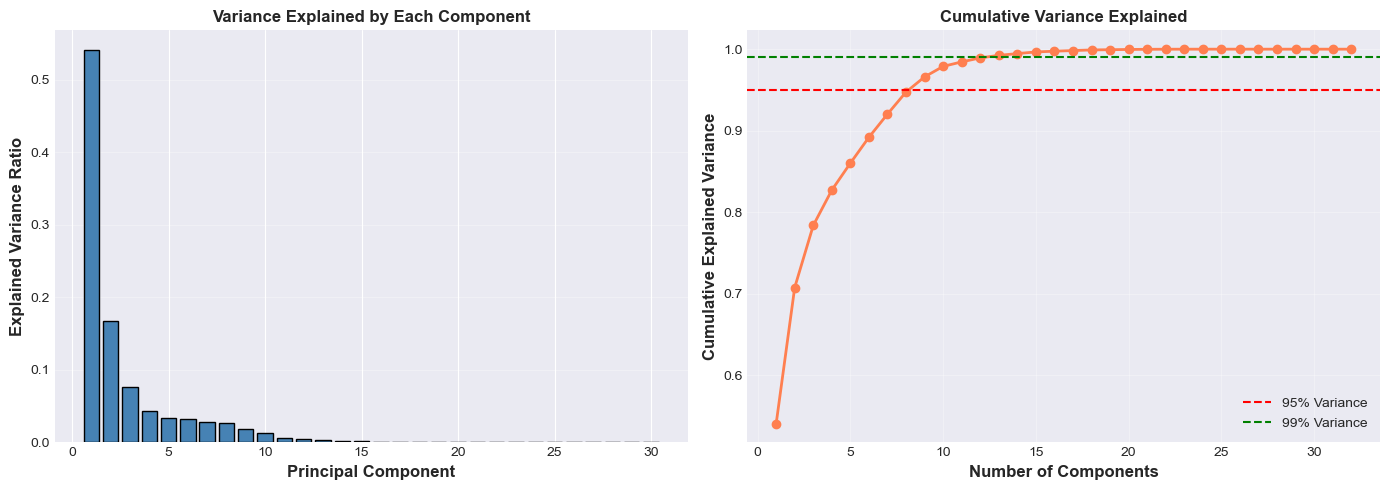

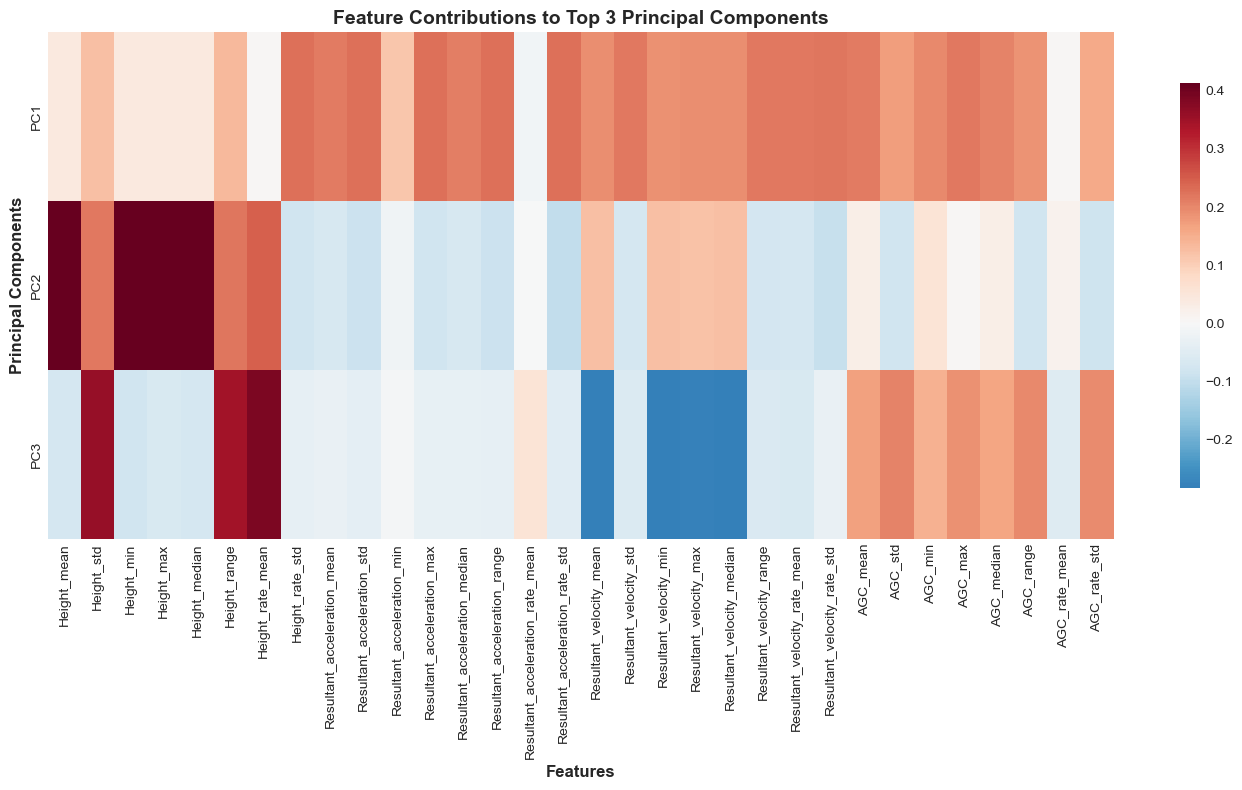


✓ PCA analysis completed


In [13]:
# ============================================================================
# CELL 13
# ============================================================================
print("="*80)
print("FEATURE SELECTION - PCA ANALYSIS")
print("="*80)
# Apply PCA
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train)
# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(f"\n✓ PCA Analysis:")
print(f"   Total components: {len(explained_variance)}")
print(f"   Variance explained by top 10 components: {cumulative_variance[9]:.4f}")
print(f"   Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"   Components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Individual variance
axes[0].bar(range(1, min(31, len(explained_variance)+1)), explained_variance[:30], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0].set_title('Variance Explained by Each Component', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='coral', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
axes[1].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Variance Explained', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'pca_variance_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
# Component contribution to original features
n_components_to_show = 3
components_df = pd.DataFrame(
    pca.components_[:n_components_to_show],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_components_to_show)]
)
# Visualize component loadings
plt.figure(figsize=(14, 8))
sns.heatmap(components_df, cmap='RdBu_r', center=0, annot=False, cbar_kws={"shrink": 0.8})
plt.title(f'Feature Contributions to Top {n_components_to_show} Principal Components', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Principal Components', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'pca_component_loadings.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ PCA analysis completed")



CONSENSUS FEATURE SELECTION

Top 20 Features by Consensus Ranking:
                            Feature  ANOVA_Score  MI_Score  RF_Score  \
7                   Height_rate_std     0.833386  1.000000  1.000000   
13     Resultant_acceleration_range     0.833386  0.761398  0.448635   
26                          AGC_min     1.000000  0.689022  0.792753   
27                          AGC_max     0.902798  0.797378  0.726181   
21         Resultant_velocity_range     0.833386  0.876016  0.416954   
24                         AGC_mean     0.833386  0.782331  0.731410   
15  Resultant_acceleration_rate_std     0.833386  0.793530  0.512026   
17           Resultant_velocity_std     0.833386  0.853652  0.401256   
22     Resultant_velocity_rate_mean     0.833386  0.891457  0.463348   
23      Resultant_velocity_rate_std     0.833386  0.771849  0.415196   
0                       Height_mean     0.833386  0.302280  0.039324   
9        Resultant_acceleration_std     0.833386  0.783590  0.404874 

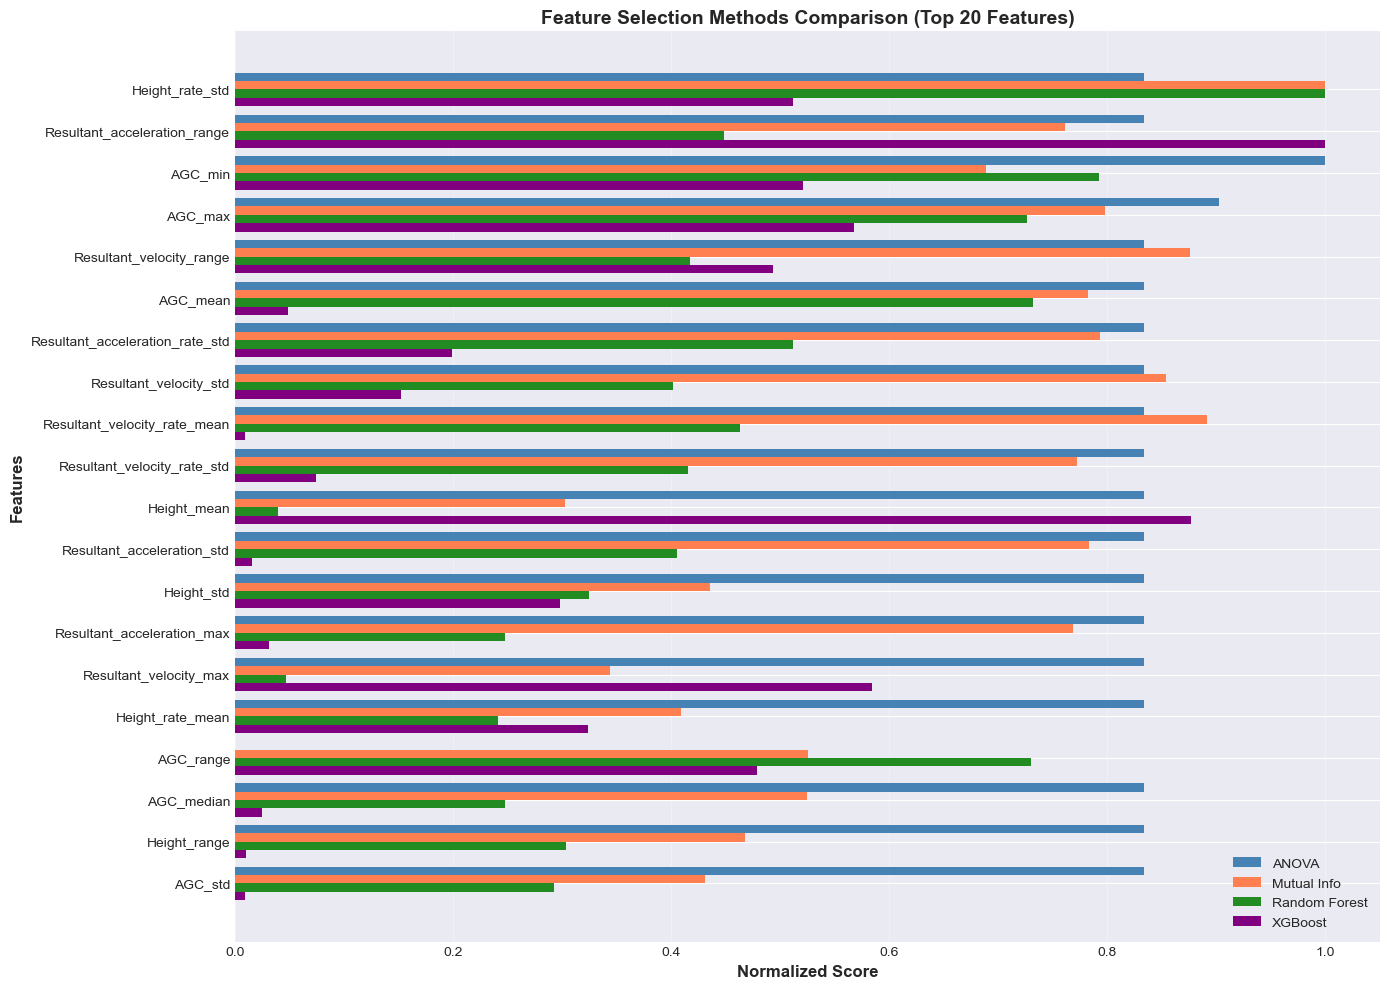

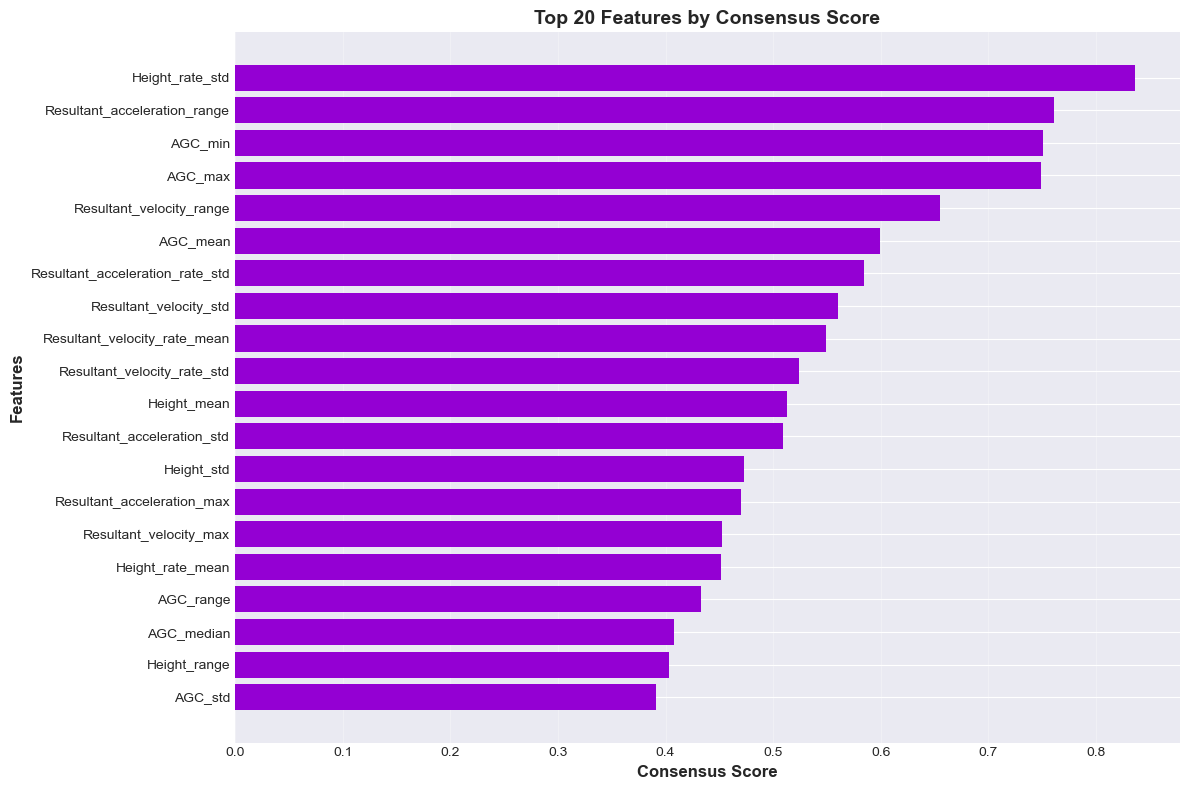


✓ Feature rankings saved to reports/


In [14]:
# ============================================================================
# CELL 14
# ============================================================================
print("="*80)
print("CONSENSUS FEATURE SELECTION")
print("="*80)
# Normalize scores to 0-1 range for comparison
def normalize_scores(scores):
    return (scores - scores.min()) / (scores.max() - scores.min())
# Create a comprehensive feature ranking
feature_rankings = pd.DataFrame({'Feature': feature_names})
# Add normalized scores from each method
feature_rankings['ANOVA_Score'] = normalize_scores(anova_scores.set_index('Feature').loc[feature_names, 'F_Score'].values)
feature_rankings['MI_Score'] = normalize_scores(mi_scores_df.set_index('Feature').loc[feature_names, 'MI_Score'].values)
feature_rankings['RF_Score'] = normalize_scores(rf_importance.set_index('Feature').loc[feature_names, 'Importance'].values)
feature_rankings['XGB_Score'] = normalize_scores(xgb_importance.set_index('Feature').loc[feature_names, 'Importance'].values)
# Calculate consensus score (average of all methods)
feature_rankings['Consensus_Score'] = feature_rankings[['ANOVA_Score', 'MI_Score', 'RF_Score', 'XGB_Score']].mean(axis=1)
feature_rankings = feature_rankings.sort_values('Consensus_Score', ascending=False)
print("\nTop 20 Features by Consensus Ranking:")
print(feature_rankings.head(20))
# Select top N features
n_top_features = CONFIG['n_top_features']
top_features = feature_rankings.head(n_top_features)['Feature'].tolist()
print(f"\n✓ Selected Top {n_top_features} Features:")
for i, feat in enumerate(top_features, 1):
    score = feature_rankings[feature_rankings['Feature'] == feat]['Consensus_Score'].values[0]
    print(f"   {i:2d}. {feat:40s} (Score: {score:.4f})")
# Visualize consensus ranking
plt.figure(figsize=(14, 10))
top_20 = feature_rankings.head(20)
x = range(len(top_20))
width = 0.2
plt.barh([i - 1.5*width for i in x], top_20['ANOVA_Score'], width, label='ANOVA', color='steelblue')
plt.barh([i - 0.5*width for i in x], top_20['MI_Score'], width, label='Mutual Info', color='coral')
plt.barh([i + 0.5*width for i in x], top_20['RF_Score'], width, label='Random Forest', color='forestgreen')
plt.barh([i + 1.5*width for i in x], top_20['XGB_Score'], width, label='XGBoost', color='purple')
plt.yticks(x, top_20['Feature'])
plt.xlabel('Normalized Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Feature Selection Methods Comparison (Top 20 Features)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'consensus_feature_ranking.png'), dpi=300, bbox_inches='tight')
plt.show()
# Visualize consensus scores
plt.figure(figsize=(12, 8))
top_features_plot = feature_rankings.head(20)
plt.barh(range(len(top_features_plot)), top_features_plot['Consensus_Score'], color='darkviolet')
plt.yticks(range(len(top_features_plot)), top_features_plot['Feature'])
plt.xlabel('Consensus Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by Consensus Score', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'final_consensus_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
# Save feature rankings
feature_rankings.to_csv(os.path.join(REPORTS_DIR, 'feature_rankings.csv'), index=False)
print(f"\n✓ Feature rankings saved to reports/")


APPLYING FEATURE SELECTION

✓ Feature selection applied!
   Original features: 32
   Selected features: 15
   Reduction: 53.1%

   Training set shape: (677, 15)
   Test set shape: (291, 15)


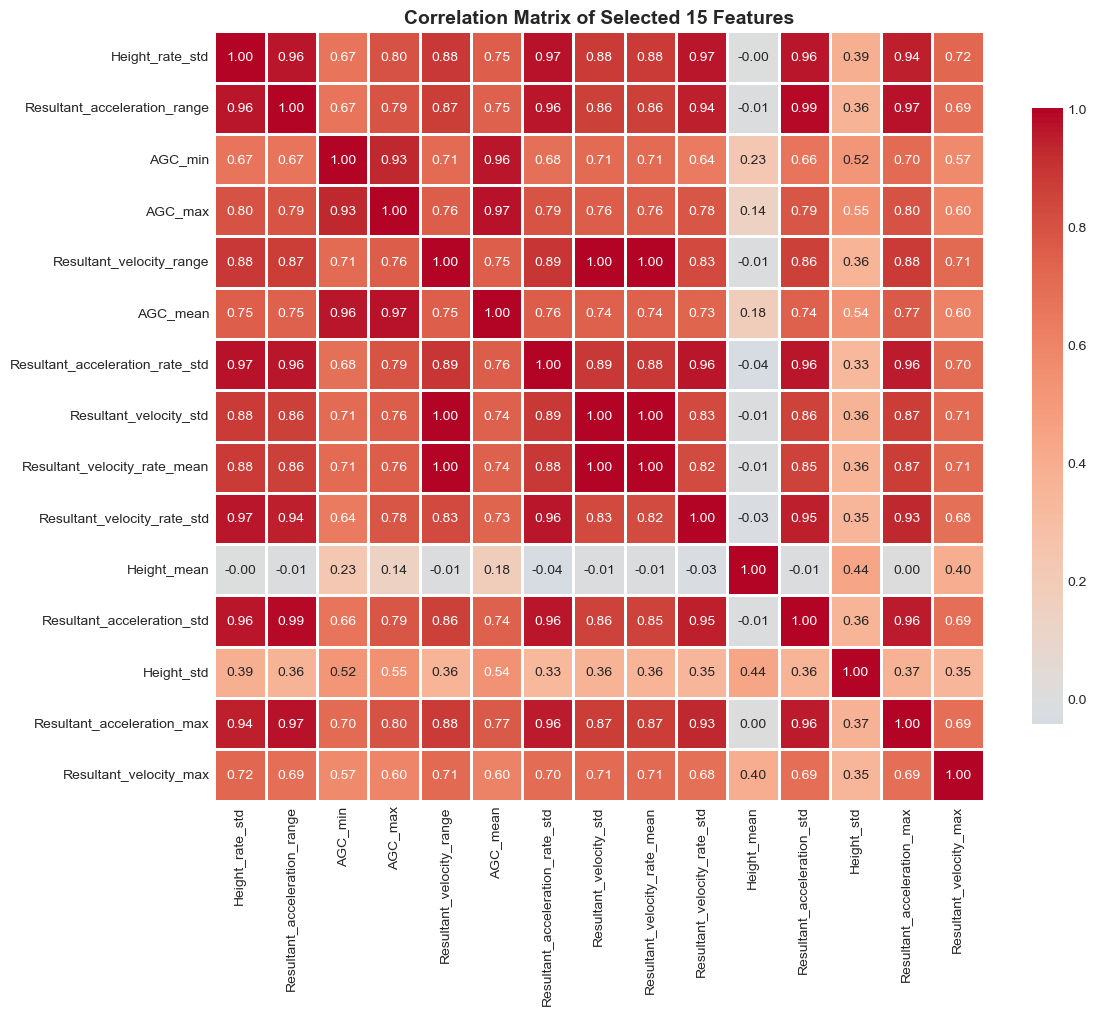


✓ Selected features data saved


In [15]:
# ============================================================================
# CELL 15
# ============================================================================
print("="*80)
print("APPLYING FEATURE SELECTION")
print("="*80)
# Select top features from training and test sets
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]
print(f"\n✓ Feature selection applied!")
print(f"   Original features: {X_train.shape[1]}")
print(f"   Selected features: {X_train_selected.shape[1]}")
print(f"   Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"\n   Training set shape: {X_train_selected.shape}")
print(f"   Test set shape: {X_test_selected.shape}")
# Visualize feature correlation after selection
plt.figure(figsize=(12, 10))
correlation_selected = X_train_selected.corr()
sns.heatmap(correlation_selected, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title(f'Correlation Matrix of Selected {n_top_features} Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'selected_features_correlation.png'), dpi=300, bbox_inches='tight')
plt.show()
# Save selected features data
X_train_selected.to_csv(os.path.join(DATA_PROCESSED_DIR, 'X_train_selected.csv'), index=False)
X_test_selected.to_csv(os.path.join(DATA_PROCESSED_DIR, 'X_test_selected.csv'), index=False)
y_train.to_csv(os.path.join(DATA_PROCESSED_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(DATA_PROCESSED_DIR, 'y_test.csv'), index=False)
print("\n✓ Selected features data saved")

FEATURE IMPACT ANALYSIS

Analyzing feature impact on class separation...


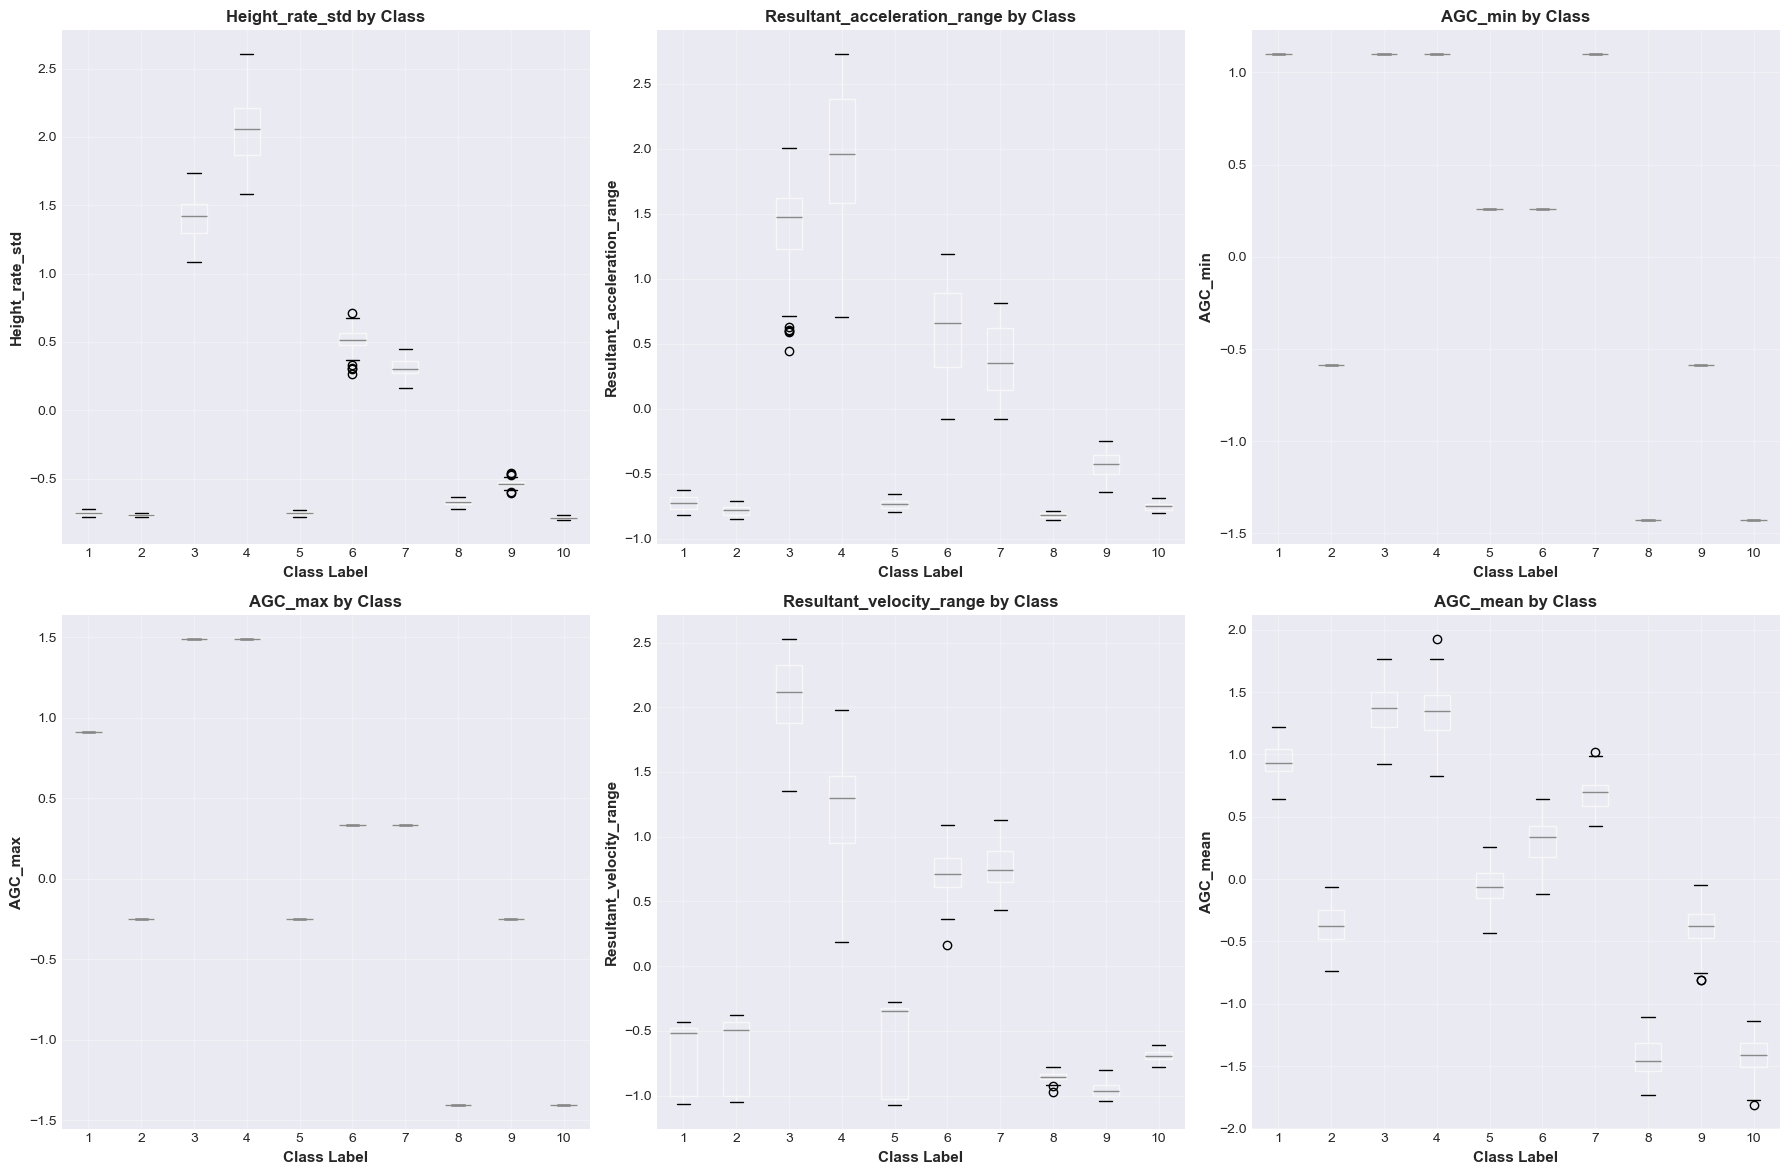


Generating pairwise scatter plots...


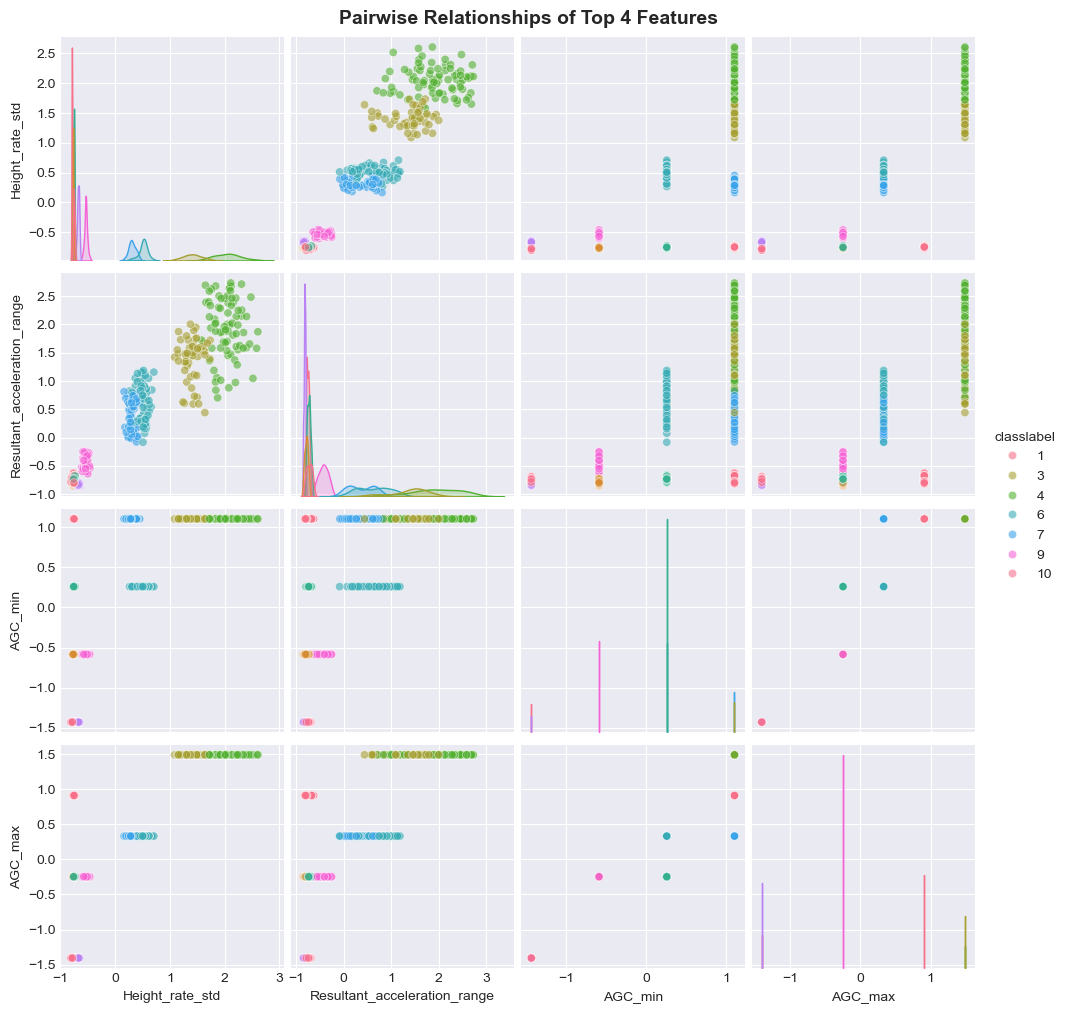


✓ Feature impact analysis completed


In [16]:
# ============================================================================
# CELL 16
# ============================================================================
print("="*80)
print("FEATURE IMPACT ANALYSIS")
print("="*80)
# Analyze how selected features separate classes
print("\nAnalyzing feature impact on class separation...")
# Select top 6 features for detailed analysis
top_6_features = top_features[:6]
# Create box plots for each selected feature by class
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
for idx, feature in enumerate(top_6_features):
    # Combine train data for visualization
    plot_data = pd.DataFrame({
        'Feature_Value': X_train_selected[feature],
        'Class': y_train
    })
    # Box plot
    plot_data.boxplot(column='Feature_Value', by='Class', ax=axes[idx])
    axes[idx].set_xlabel('Class Label', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} by Class', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'top_features_class_separation.png'), dpi=300, bbox_inches='tight')
plt.show()
# Pairwise scatter plots of top 4 features
print("\nGenerating pairwise scatter plots...")
plot_df = X_train_selected[top_features[:4]].copy()
plot_df['classlabel'] = y_train.values
pairplot = sns.pairplot(plot_df, hue='classlabel', diag_kind='kde', palette='husl', plot_kws={'alpha': 0.6})
pairplot.fig.suptitle('Pairwise Relationships of Top 4 Features', y=1.01, fontsize=14, fontweight='bold')
plt.savefig(os.path.join(FEATURE_SEL_FIGURES_DIR, 'top4_features_pairplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Feature impact analysis completed")



In [17]:
# ============================================================================
# CELL 17
# ============================================================================
print("="*80)
print("INITIALIZING MACHINE LEARNING MODELS")
print("="*80)
# Define all classification models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    'Support Vector Machine': SVC(
        kernel='rbf',
        random_state=RANDOM_STATE,
        probability=True
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=10
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    # ),
    # 'Neural Network': MLPClassifier(
    #     hidden_layers=(100, 50),
    #     max_iter=500,
    #     random_state=RANDOM_STATE
    # )
}
print(f"\n✓ Initialized {len(models)} classification models:")
for i, model_name in enumerate(models.keys(), 1):
    print(f"   {i}. {model_name}")
print("\nReady for training!")


INITIALIZING MACHINE LEARNING MODELS

✓ Initialized 7 classification models:
   1. Logistic Regression
   2. K-Nearest Neighbors
   3. Support Vector Machine
   4. Decision Tree
   5. Random Forest
   6. Gradient Boosting
   7. XGBoost

Ready for training!


In [18]:
# print("="*80)
# print("MODEL TRAINING - TRAIN-TEST SPLIT APPROACH")
# print("="*80)

# # Dictionary to store results
# results_train_test = {}
# trained_models = {}

# print("\nTraining models on training set...\n")

# for model_name, model in models.items():
#     print(f"Training {model_name}...")
#     start_time = datetime.now()
    
#     # Train model
#     model.fit(X_train_selected, y_train)
    
#     # Make predictions
#     y_train_pred = model.predict(X_train_selected)
#     y_test_pred = model.predict(X_test_selected)
    
#     # Calculate metrics
#     train_accuracy = accuracy_score(y_train, y_train_pred)
#     test_accuracy = accuracy_score(y_test, y_test_pred)
    
#     # Store results
#     results_train_test[model_name] = {
#         'model': model,
#         'train_accuracy': train_accuracy,
#         'test_accuracy': test_accuracy,
#         'train_predictions': y_train_pred,
#         'test_predictions': y_test_pred,
#         'training_time': (datetime.now() - start_time).total_seconds()
#     }
    
#     trained_models[model_name] = model
    
#     print(f"   ✓ Train Accuracy: {train_accuracy:.4f}")
#     print(f"   ✓ Test Accuracy: {test_accuracy:.4f}")
#     print(f"   ✓ Overfitting Gap: {(train_accuracy - test_accuracy):.4f}")
#     print(f"   ✓ Training Time: {results_train_test[model_name]['training_time']:.2f}s\n")

# print("="*80)
# print("✓ All models trained successfully!")
# print("="*80)



# ============================================================================
# CELL 18
# ============================================================================
print("="*80)
print("MODEL TRAINING - TRAIN-TEST SPLIT APPROACH")
print("="*80)
# Dictionary to store results
results_train_test = {}
trained_models = {}
print("\nTraining models on training set...\n")
for model_name, model in models.items():
    print(f"Training {model_name}...")
    start_time = datetime.now()
    
    # Use 0-indexed labels for XGBoost, original labels for others
    if 'XGBoost' in model_name:
        y_train_use = y_train - 1
        y_test_use = y_test - 1
    else:
        y_train_use = y_train
        y_test_use = y_test
    # Train model
    model.fit(X_train_selected, y_train_use)
    # Make predictions
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)
    # Convert XGBoost predictions back to 1-10
    if 'XGBoost' in model_name:
        y_train_pred = y_train_pred + 1
        y_test_pred = y_test_pred + 1
    # Calculate metrics (use original labels)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    # Store results
    results_train_test[model_name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_predictions': y_train_pred,
        'test_predictions': y_test_pred,
        'training_time': (datetime.now() - start_time).total_seconds()
    }
    trained_models[model_name] = model
    print(f"  ✓ Train Accuracy: {train_accuracy:.4f}")
    print(f"  ✓ Test Accuracy: {test_accuracy:.4f}")
    print(f"  ✓ Overfitting Gap: {(train_accuracy - test_accuracy):.4f}")
    print(f"  ✓ Training Time: {results_train_test[model_name]['training_time']:.2f}s\n")
print("="*80)
print("✓ All models trained successfully!")
print("="*80)


MODEL TRAINING - TRAIN-TEST SPLIT APPROACH

Training models on training set...

Training Logistic Regression...
  ✓ Train Accuracy: 0.9985
  ✓ Test Accuracy: 0.9897
  ✓ Overfitting Gap: 0.0088
  ✓ Training Time: 6.19s

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 0.9897
  ✓ Test Accuracy: 0.9794
  ✓ Overfitting Gap: 0.0103
  ✓ Training Time: 0.14s

Training Support Vector Machine...
  ✓ Train Accuracy: 0.9911
  ✓ Test Accuracy: 0.9863
  ✓ Overfitting Gap: 0.0049
  ✓ Training Time: 0.14s

Training Decision Tree...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.9897
  ✓ Overfitting Gap: 0.0103
  ✓ Training Time: 0.02s

Training Random Forest...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.9966
  ✓ Overfitting Gap: 0.0034
  ✓ Training Time: 0.44s

Training Gradient Boosting...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.9897
  ✓ Overfitting Gap: 0.0103
  ✓ Training Time: 5.63s

Training XGBoost...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.9897
  ✓ Overfitting Gap: 0.0

In [19]:
# ============================================================================
# CELL 19
# ============================================================================
print("="*80)
print("MODEL EVALUATION - DETAILED METRICS")
print("="*80)
# Create comprehensive evaluation report
evaluation_results = []
for model_name in models.keys():
    result = results_train_test[model_name]
    # Calculate detailed metrics
    test_precision = precision_score(y_test, result['test_predictions'], average='weighted', zero_division=0)
    test_recall = recall_score(y_test, result['test_predictions'], average='weighted', zero_division=0)
    test_f1 = f1_score(y_test, result['test_predictions'], average='weighted', zero_division=0)
    evaluation_results.append({
        'Model': model_name,
        'Train_Accuracy': result['train_accuracy'],
        'Test_Accuracy': result['test_accuracy'],
        'Precision': test_precision,
        'Recall': test_recall,
        'F1_Score': test_f1,
        'Overfitting_Gap': result['train_accuracy'] - result['test_accuracy'],
        'Training_Time': result['training_time']
    })
# Create DataFrame
eval_df = pd.DataFrame(evaluation_results).sort_values('Test_Accuracy', ascending=False)
print("\nModel Performance Comparison:")
print("="*100)
print(eval_df.to_string(index=False))
print("="*100)
# Identify best model
best_model_name = eval_df.iloc[0]['Model']
best_accuracy = eval_df.iloc[0]['Test_Accuracy']
print(f"\n🏆 Best Model: {best_model_name} with Test Accuracy: {best_accuracy:.4f}")
# Check for overfitting
print("\n📊 Overfitting Analysis:")
for _, row in eval_df.iterrows():
    gap = row['Overfitting_Gap']
    status = "⚠ OVERFITTING" if gap > 0.10 else "✓ Good" if gap > 0 else "⚠ UNDERFITTING"
    print(f"   {row['Model']:25s}: Gap = {gap:+.4f} [{status}]")
# Save evaluation results
eval_df.to_csv(os.path.join(REPORTS_DIR, 'model_comparison.csv'), index=False)
print(f"\n✓ Evaluation results saved to reports/")


MODEL EVALUATION - DETAILED METRICS

Model Performance Comparison:
                 Model  Train_Accuracy  Test_Accuracy  Precision   Recall  F1_Score  Overfitting_Gap  Training_Time
         Random Forest        1.000000       0.996564   0.996662 0.996564  0.996549         0.003436       0.444896
         Decision Tree        1.000000       0.989691   0.989885 0.989691  0.989728         0.010309       0.015941
   Logistic Regression        0.998523       0.989691   0.989723 0.989691  0.989646         0.008832       6.190674
     Gradient Boosting        1.000000       0.989691   0.990161 0.989691  0.989621         0.010309       5.633252
               XGBoost        1.000000       0.989691   0.990527 0.989691  0.989531         0.010309       0.232519
Support Vector Machine        0.991137       0.986254   0.986388 0.986254  0.986212         0.004883       0.135007
   K-Nearest Neighbors        0.989660       0.979381   0.979381 0.979381  0.979381         0.010279       0.140002

🏆 Be

MODEL COMPARISON VISUALIZATION


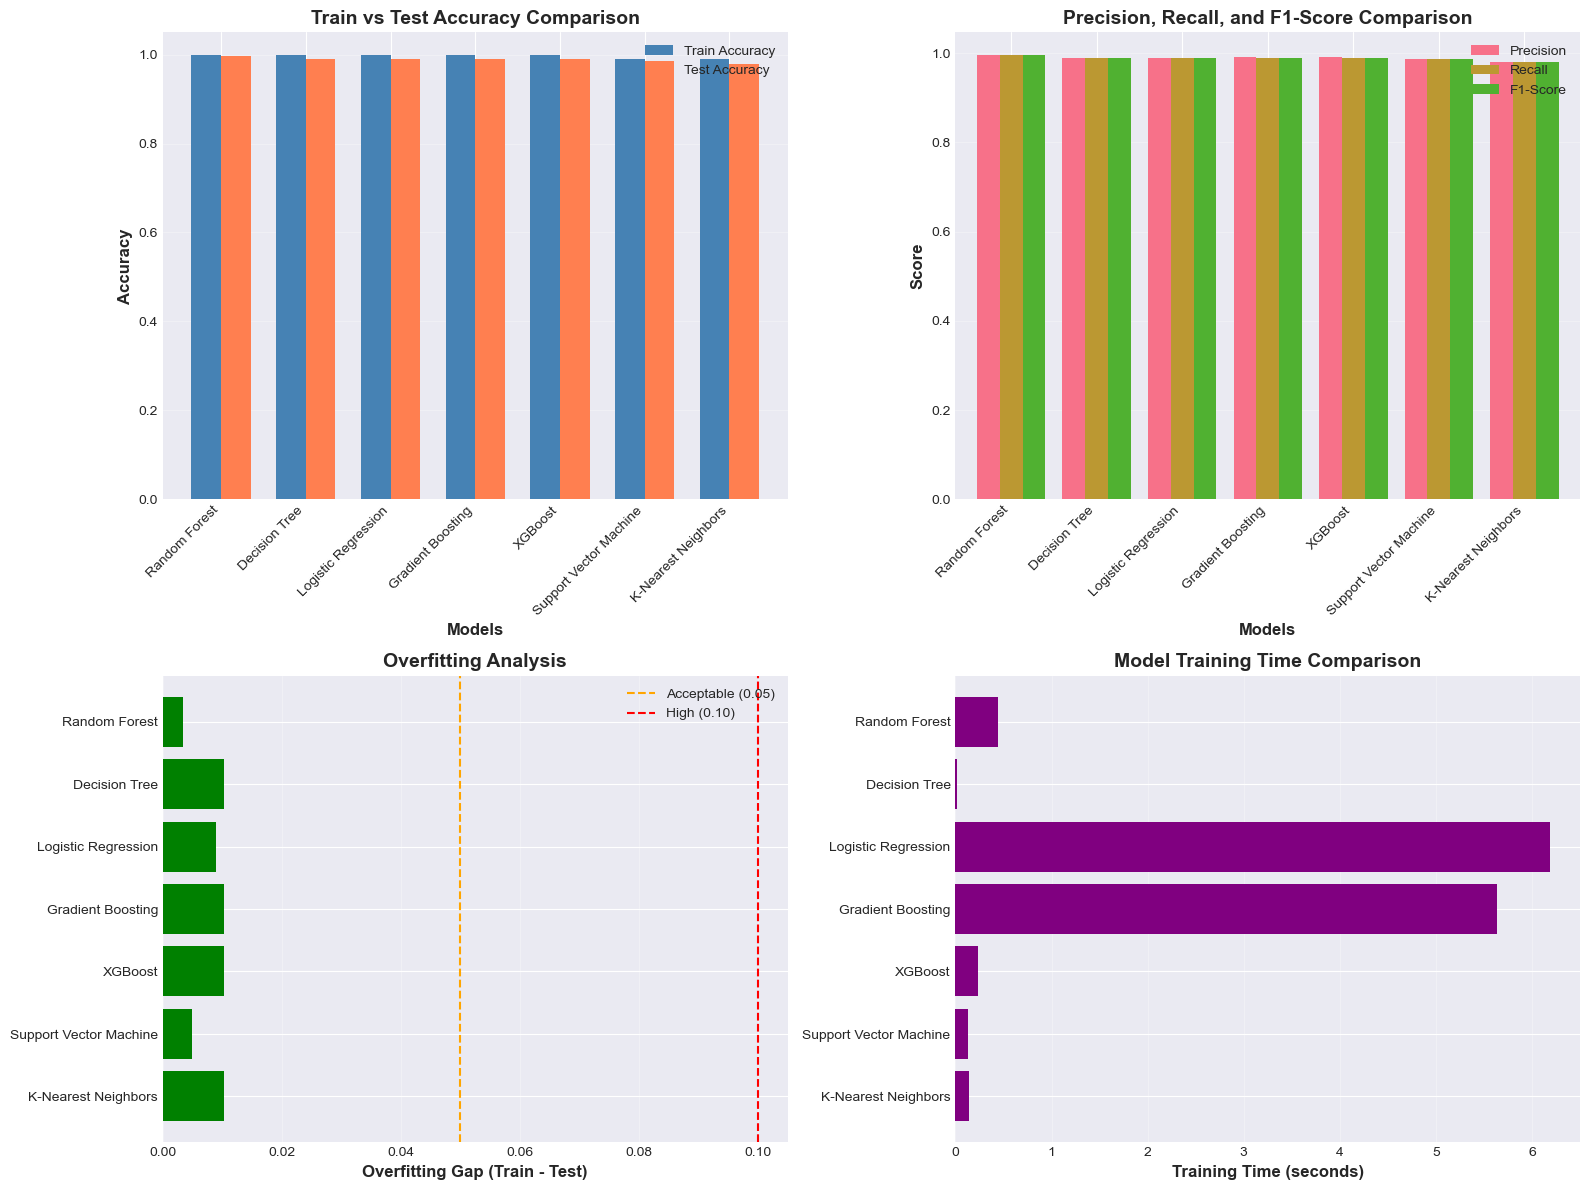


✓ Model comparison visualizations saved


In [20]:

# ============================================================================
# CELL 20
# ============================================================================print("="*80)
print("MODEL COMPARISON VISUALIZATION")
print("="*80)
# 1. Accuracy Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Train vs Test Accuracy
x_pos = np.arange(len(eval_df))
width = 0.35
axes[0, 0].bar(x_pos - width/2, eval_df['Train_Accuracy'], width, label='Train Accuracy', color='steelblue')
axes[0, 0].bar(x_pos + width/2, eval_df['Test_Accuracy'], width, label='Test Accuracy', color='coral')
axes[0, 0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Train vs Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(eval_df['Model'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
# Precision, Recall, F1-Score
metrics_data = eval_df[['Model', 'Precision', 'Recall', 'F1_Score']].set_index('Model')
metrics_data.plot(kind='bar', ax=axes[0, 1], width=0.8)
axes[0, 1].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Precision, Recall, and F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(eval_df['Model'], rotation=45, ha='right')
axes[0, 1].legend(['Precision', 'Recall', 'F1-Score'])
axes[0, 1].grid(axis='y', alpha=0.3)
# Overfitting Gap
colors = ['green' if gap <= 0.05 else 'orange' if gap <= 0.10 else 'red' 
          for gap in eval_df['Overfitting_Gap']]
axes[1, 0].barh(range(len(eval_df)), eval_df['Overfitting_Gap'], color=colors)
axes[1, 0].set_yticks(range(len(eval_df)))
axes[1, 0].set_yticklabels(eval_df['Model'])
axes[1, 0].set_xlabel('Overfitting Gap (Train - Test)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0.05, color='orange', linestyle='--', label='Acceptable (0.05)')
axes[1, 0].axvline(x=0.10, color='red', linestyle='--', label='High (0.10)')
axes[1, 0].legend()
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()
# Training Time
axes[1, 1].barh(range(len(eval_df)), eval_df['Training_Time'], color='purple')
axes[1, 1].set_yticks(range(len(eval_df)))
axes[1, 1].set_yticklabels(eval_df['Model'])
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PERF_FIGURES_DIR, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Model comparison visualizations saved")



CONFUSION MATRICES


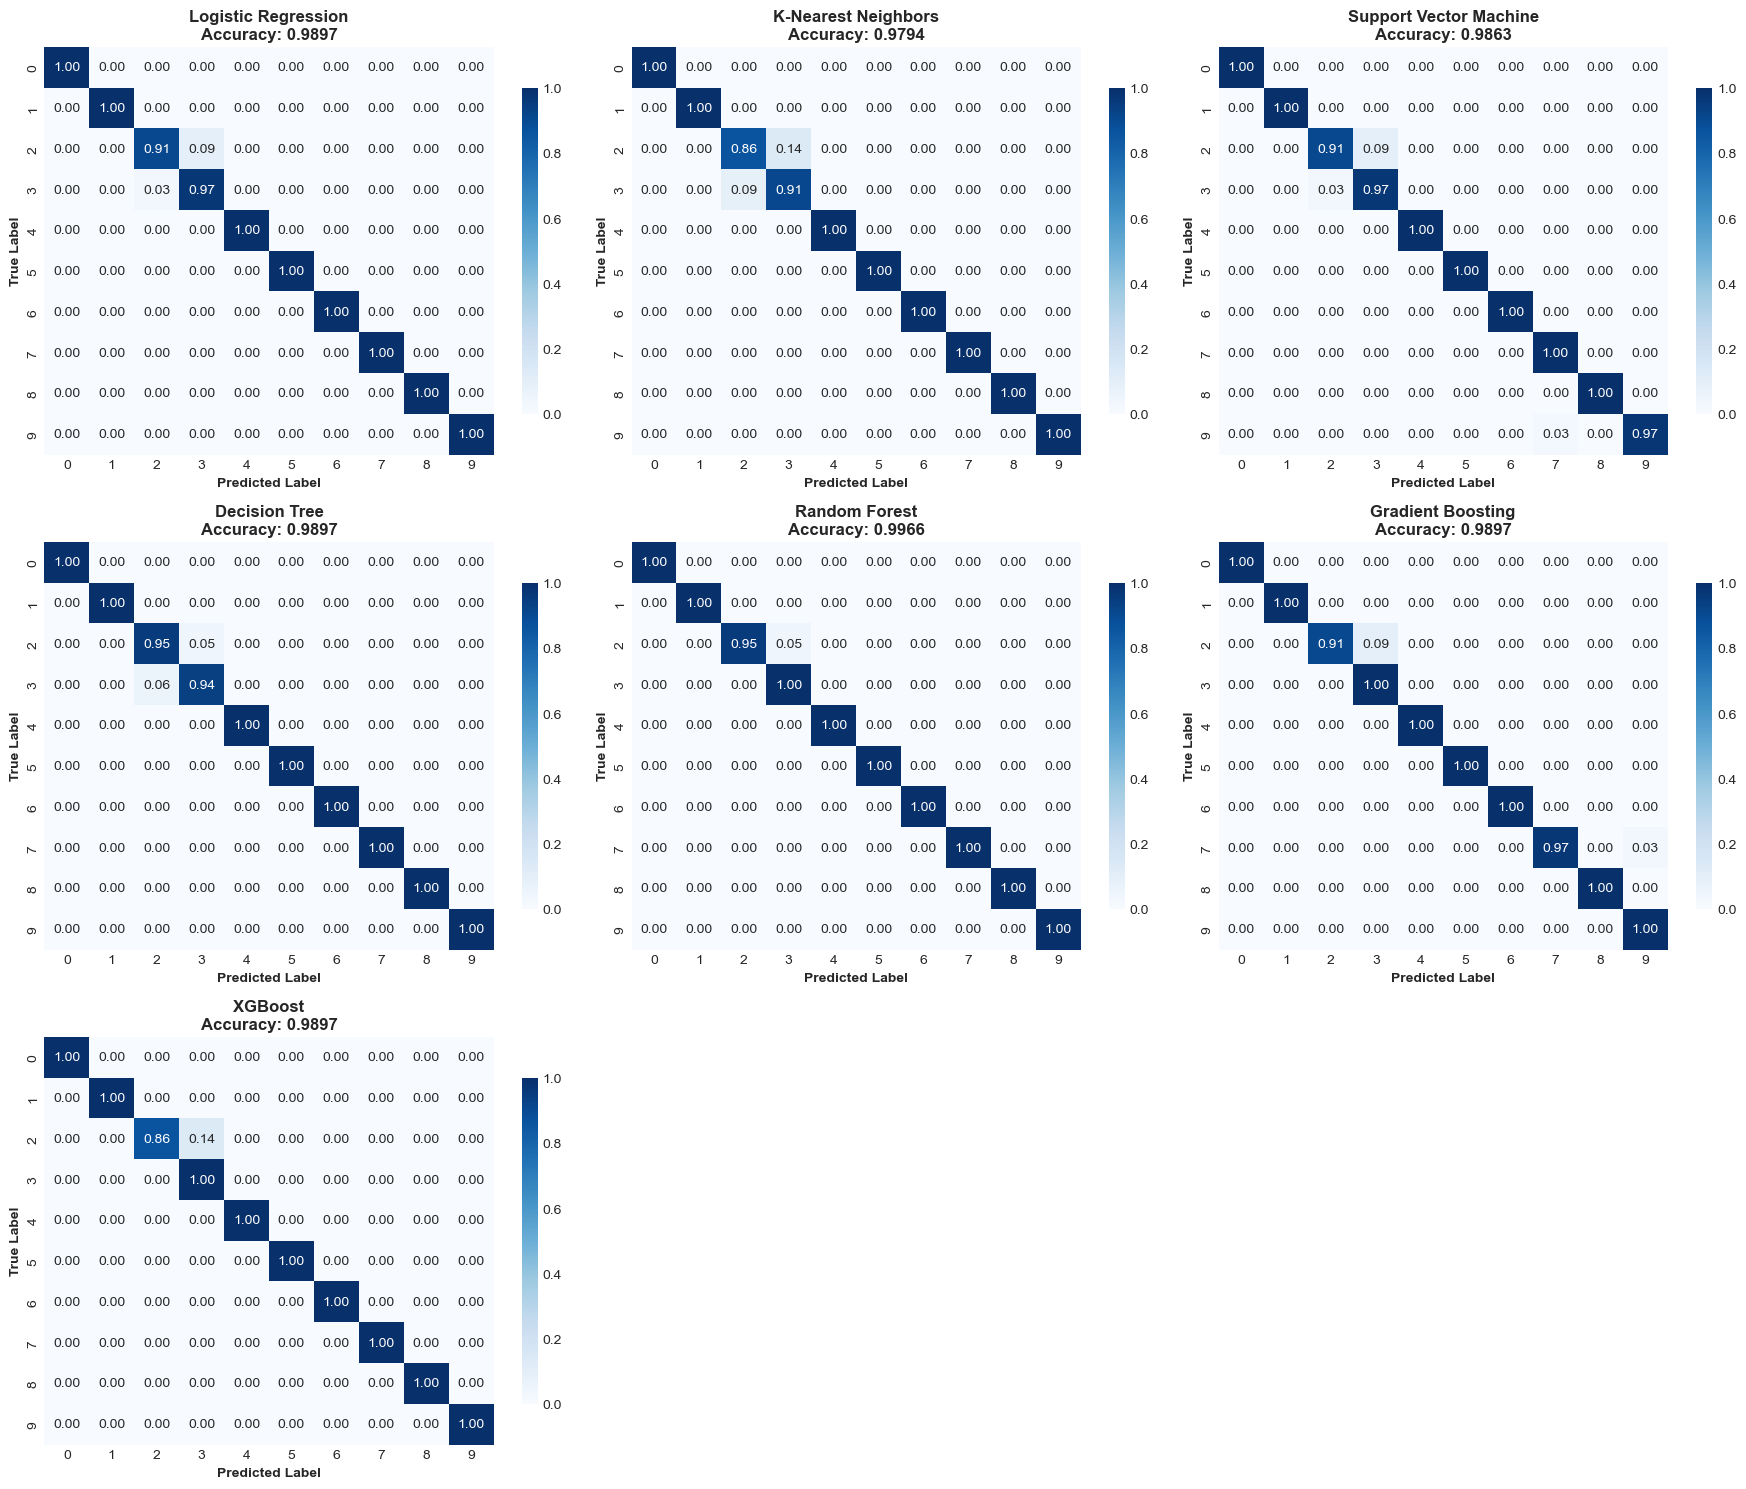


Detailed Confusion Matrix for Best Model: Random Forest


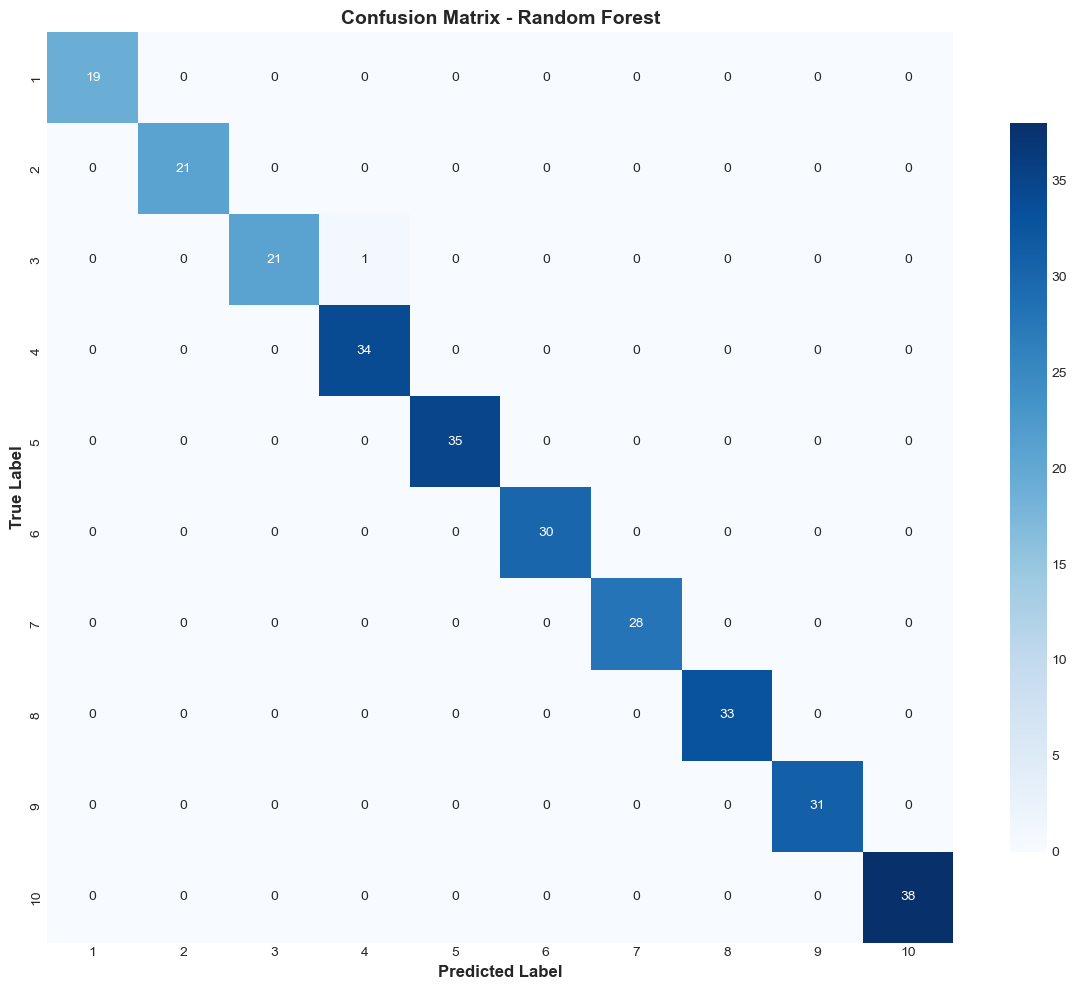


✓ Confusion matrices saved


In [21]:
# ============================================================================
# CELL 21
# ============================================================================
print("="*80)
print("CONFUSION MATRICES")
print("="*80)
# Generate confusion matrices for all models
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.ravel()
for idx, (model_name, result) in enumerate(results_train_test.items()):
    cm = confusion_matrix(y_test, result['test_predictions'])
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    # Plot
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                ax=axes[idx], cbar_kws={"shrink": 0.8})
    axes[idx].set_title(f'{model_name}\nAccuracy: {result["test_accuracy"]:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10, fontweight='bold')
# Remove empty subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.savefig(os.path.join(CONFUSION_MAT_DIR, 'all_models_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()
# Generate detailed confusion matrix for best model
print(f"\nDetailed Confusion Matrix for Best Model: {best_model_name}")
best_result = results_train_test[best_model_name]
cm_best = confusion_matrix(y_test, best_result['test_predictions'])
plt.figure(figsize=(12, 10))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y_test.unique()), 
            yticklabels=sorted(y_test.unique()),
            cbar_kws={"shrink": 0.8})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFUSION_MAT_DIR, f'best_model_{best_model_name.replace(" ", "_")}_cm.png'), 
            dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Confusion matrices saved")


In [22]:
# ============================================================================
# CELL 22
# ============================================================================
print("="*80)
print("CLASSIFICATION REPORTS")
print("="*80)
# Generate classification report for each model
for model_name, result in results_train_test.items():
    print(f"\n{'='*80}")
    print(f"Classification Report: {model_name}")
    print(f"{'='*80}")
    report = classification_report(y_test, result['test_predictions'], zero_division=0)
    print(report)
    # Save to file
    report_path = os.path.join(REPORTS_DIR, f'{model_name.replace(" ", "_")}_classification_report.txt')
    with open(report_path, 'w') as f:
        f.write(f"Classification Report: {model_name}\n")
        f.write("="*80 + "\n")
        f.write(report)
    print(f"✓ Report saved to: {report_path}")
print("\n✓ All classification reports generated")

CLASSIFICATION REPORTS

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        21
           3       0.95      0.91      0.93        22
           4       0.94      0.97      0.96        34
           5       1.00      1.00      1.00        35
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        28
           8       1.00      1.00      1.00        33
           9       1.00      1.00      1.00        31
          10       1.00      1.00      1.00        38

    accuracy                           0.99       291
   macro avg       0.99      0.99      0.99       291
weighted avg       0.99      0.99      0.99       291

✓ Report saved to: C:\Users\Satyajit\Desktop\Real-Time-TGT\results\reports\Logistic_Regression_classification_report.txt

Classification Report: K-Nearest Neighbors
         

In [23]:
# print("="*80)
# print("K-FOLD CROSS-VALIDATION")
# print("="*80)

# # Perform k-fold cross-validation for all models
# cv_folds = CONFIG['cv_folds']
# cv_results = {}

# print(f"\nPerforming {cv_folds}-Fold Cross-Validation...\n")

# for model_name, model in models.items():
#     print(f"Cross-validating {model_name}...")
    
#     # Perform cross-validation
#     cv_scores = cross_val_score(model, X_train_selected, y_train, 
#                                 cv=cv_folds, scoring='accuracy', n_jobs=-1)
    
#     cv_results[model_name] = {
#         'scores': cv_scores,
#         'mean': cv_scores.mean(),
#         'std': cv_scores.std()
#     }
    
#     print(f"   Fold Scores: {cv_scores}")
#     print(f"   Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})\n")

# # Create DataFrame for CV results
# cv_df = pd.DataFrame({
#     'Model': list(cv_results.keys()),
#     'CV_Mean_Accuracy': [cv_results[m]['mean'] for m in cv_results.keys()],
#     'CV_Std': [cv_results[m]['std'] for m in cv_results.keys()]
# }).sort_values('CV_Mean_Accuracy', ascending=False)

# print("\nCross-Validation Summary:")
# print("="*80)
# print(cv_df.to_string(index=False))
# print("="*80)

# # Save CV results
# cv_df.to_csv(os.path.join(REPORTS_DIR, 'cross_validation_results.csv'), index=False)

# # Visualize CV results
# plt.figure(figsize=(14, 8))

# # Box plot of CV scores
# cv_scores_list = [cv_results[m]['scores'] for m in cv_df['Model']]
# bp = plt.boxplot(cv_scores_list, labels=cv_df['Model'], patch_artist=True)

# for patch in bp['boxes']:
#     patch.set_facecolor('lightblue')

# plt.xlabel('Models', fontsize=12, fontweight='bold')
# plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
# plt.title(f'{cv_folds}-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
# plt.xticks(rotation=45, ha='right')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(MODEL_PERF_FIGURES_DIR, 'cross_validation_boxplot.png'), dpi=300, bbox_inches='tight')
# plt.show()

# # Bar plot with error bars
# plt.figure(figsize=(12, 6))
# x_pos = np.arange(len(cv_df))
# plt.bar(x_pos, cv_df['CV_Mean_Accuracy'], yerr=cv_df['CV_Std'], 
#         capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
# plt.xlabel('Models', fontsize=12, fontweight='bold')
# plt.ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
# plt.title(f'{cv_folds}-Fold Cross-Validation Mean Accuracy (with Std Dev)', fontsize=14, fontweight='bold')
# plt.xticks(x_pos, cv_df['Model'], rotation=45, ha='right')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(MODEL_PERF_FIGURES_DIR, 'cross_validation_mean_accuracy.png'), dpi=300, bbox_inches='tight')
# plt.show()

# print("\n✓ Cross-validation completed and visualizations saved")



K-FOLD CROSS-VALIDATION

Class distribution in training set:
classlabel
0    46
1    48
2    51
3    79
4    82
5    71
6    65
7    76
8    72
9    87
Name: count, dtype: int64

Minimum class size: 46

Using 5-fold cross-validation

Performing 5-Fold Cross-Validation...

Cross-validating Logistic Regression...
  Fold Scores: [0.99264706 0.97794118 0.99259259 0.99259259 0.99259259]
  Mean Accuracy: 0.9897 (±0.0059)

Cross-validating K-Nearest Neighbors...
  Fold Scores: [0.98529412 0.96323529 0.97777778 0.99259259 0.97777778]
  Mean Accuracy: 0.9793 (±0.0098)

Cross-validating Support Vector Machine...
  Fold Scores: [0.99264706 0.97794118 0.99259259 0.99259259 0.99259259]
  Mean Accuracy: 0.9897 (±0.0059)

Cross-validating Decision Tree...
  Fold Scores: [1.         1.         0.98518519 0.98518519 1.        ]
  Mean Accuracy: 0.9941 (±0.0073)

Cross-validating Random Forest...
  Fold Scores: [1.         0.99264706 0.99259259 1.         1.        ]
  Mean Accuracy: 0.9970 (±0.0036)

C

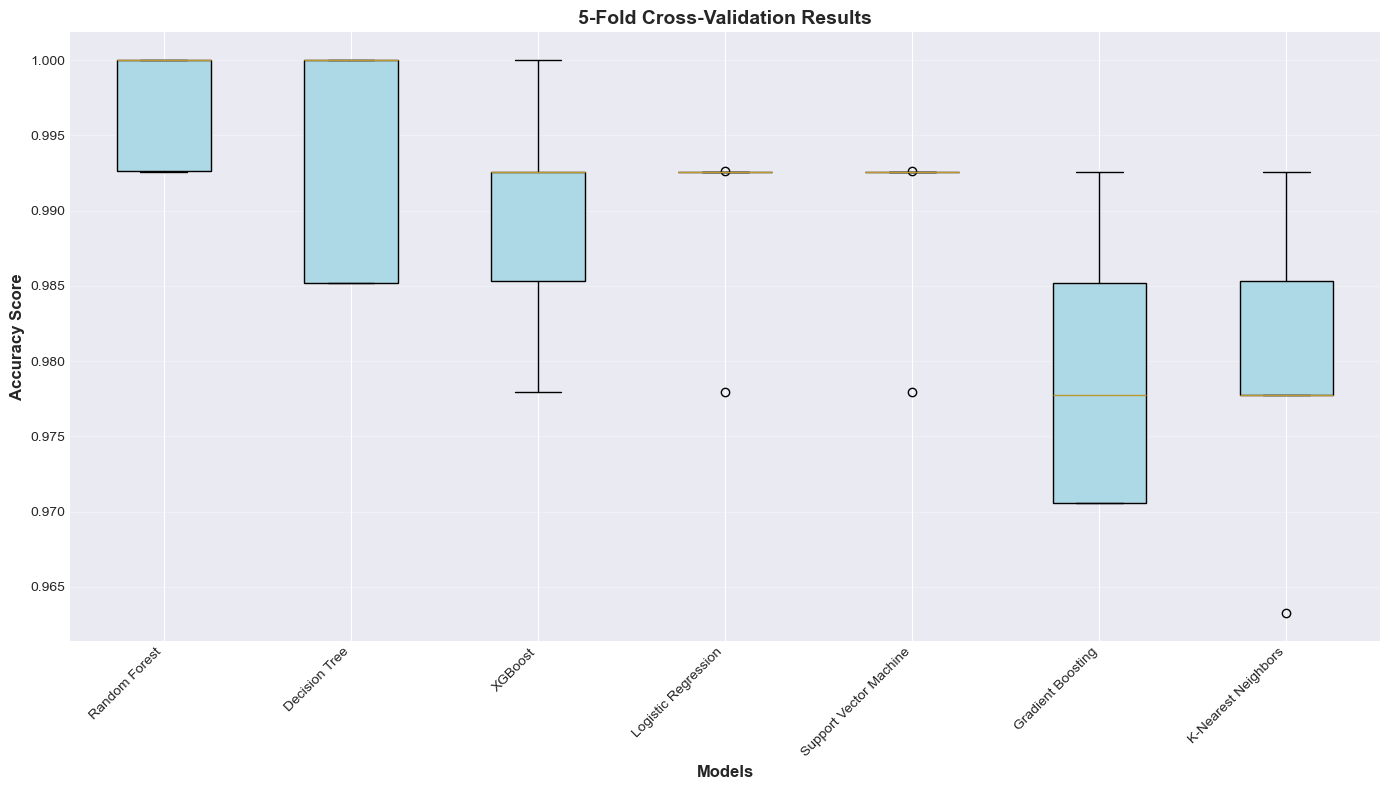

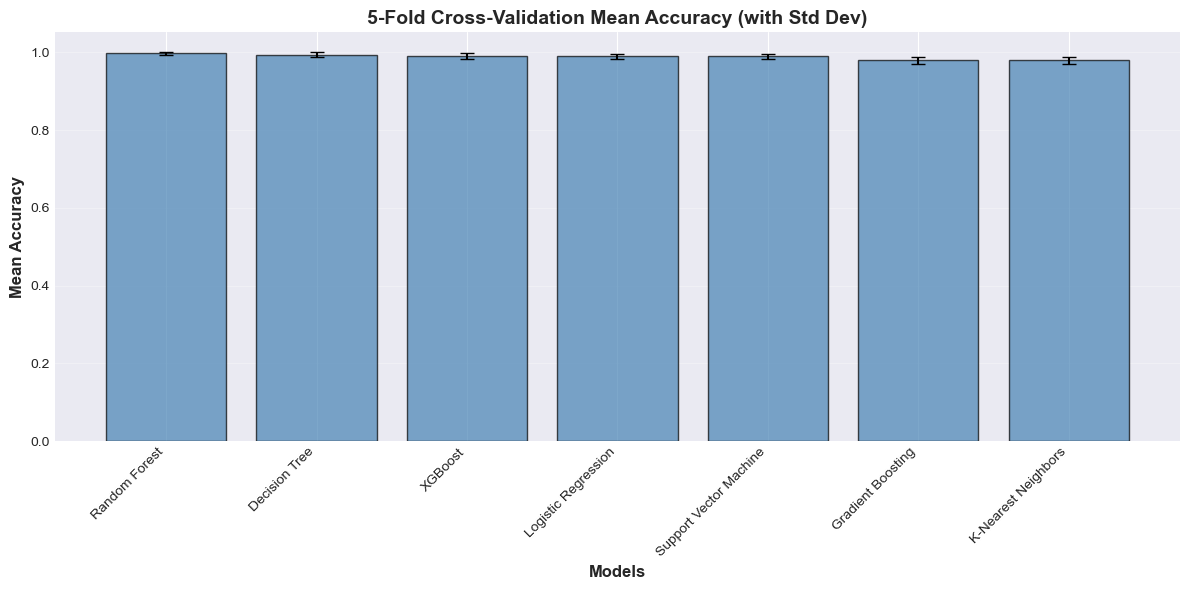


✓ Cross-validation completed and visualizations saved


In [24]:
# ============================================================================
# CELL 23
# ============================================================================
print("="*80)
print("K-FOLD CROSS-VALIDATION")
print("="*80)
# Convert labels from 1-10 to 0-9 for XGBoost compatibility
y_train_model = y_train - 1
y_test_model = y_test - 1
# Check class distribution and adjust folds if necessary
print("\nClass distribution in training set:")
class_counts = pd.Series(y_train_model).value_counts().sort_index()
print(class_counts)
min_class_size = class_counts.min()
print(f"\nMinimum class size: {min_class_size}")
# Adjust cv_folds based on minimum class size
original_folds = CONFIG['cv_folds']
cv_folds = min(original_folds, min_class_size)
if cv_folds < original_folds:
    print(f"\n⚠ WARNING: Adjusting CV folds from {original_folds} to {cv_folds} due to small class size")
else:
    print(f"\nUsing {cv_folds}-fold cross-validation")
cv_results = {}
print(f"\nPerforming {cv_folds}-Fold Cross-Validation...\n")
for model_name, model in models.items():
    print(f"Cross-validating {model_name}...")
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_selected, y_train_model,cv=cv_folds, scoring='accuracy', n_jobs=-1)
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    print(f"  Fold Scores: {cv_scores}")
    print(f"  Mean Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})\n")
# Create DataFrame for CV results
cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV_Mean_Accuracy': [cv_results[m]['mean'] for m in cv_results.keys()],
    'CV_Std': [cv_results[m]['std'] for m in cv_results.keys()]
}).sort_values('CV_Mean_Accuracy', ascending=False)
print("\nCross-Validation Summary:")
print("="*80)
print(cv_df.to_string(index=False))
print("="*80)
# Save CV results
cv_df.to_csv(os.path.join(REPORTS_DIR, 'cross_validation_results.csv'), index=False)
# Visualize CV results
plt.figure(figsize=(14, 8))
# Box plot of CV scores
cv_scores_list = [cv_results[m]['scores'] for m in cv_df['Model']]
bp = plt.boxplot(cv_scores_list, labels=cv_df['Model'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title(f'{cv_folds}-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PERF_FIGURES_DIR, 'cross_validation_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()
# Bar plot with error bars
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(cv_df))
plt.bar(x_pos, cv_df['CV_Mean_Accuracy'], yerr=cv_df['CV_Std'], capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Mean Accuracy', fontsize=12, fontweight='bold')
plt.title(f'{cv_folds}-Fold Cross-Validation Mean Accuracy (with Std Dev)', fontsize=14, fontweight='bold')
plt.xticks(x_pos, cv_df['Model'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PERF_FIGURES_DIR, 'cross_validation_mean_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Cross-validation completed and visualizations saved")

ROC CURVES (ONE-VS-REST)

Generating ROC curves for 10 classes...



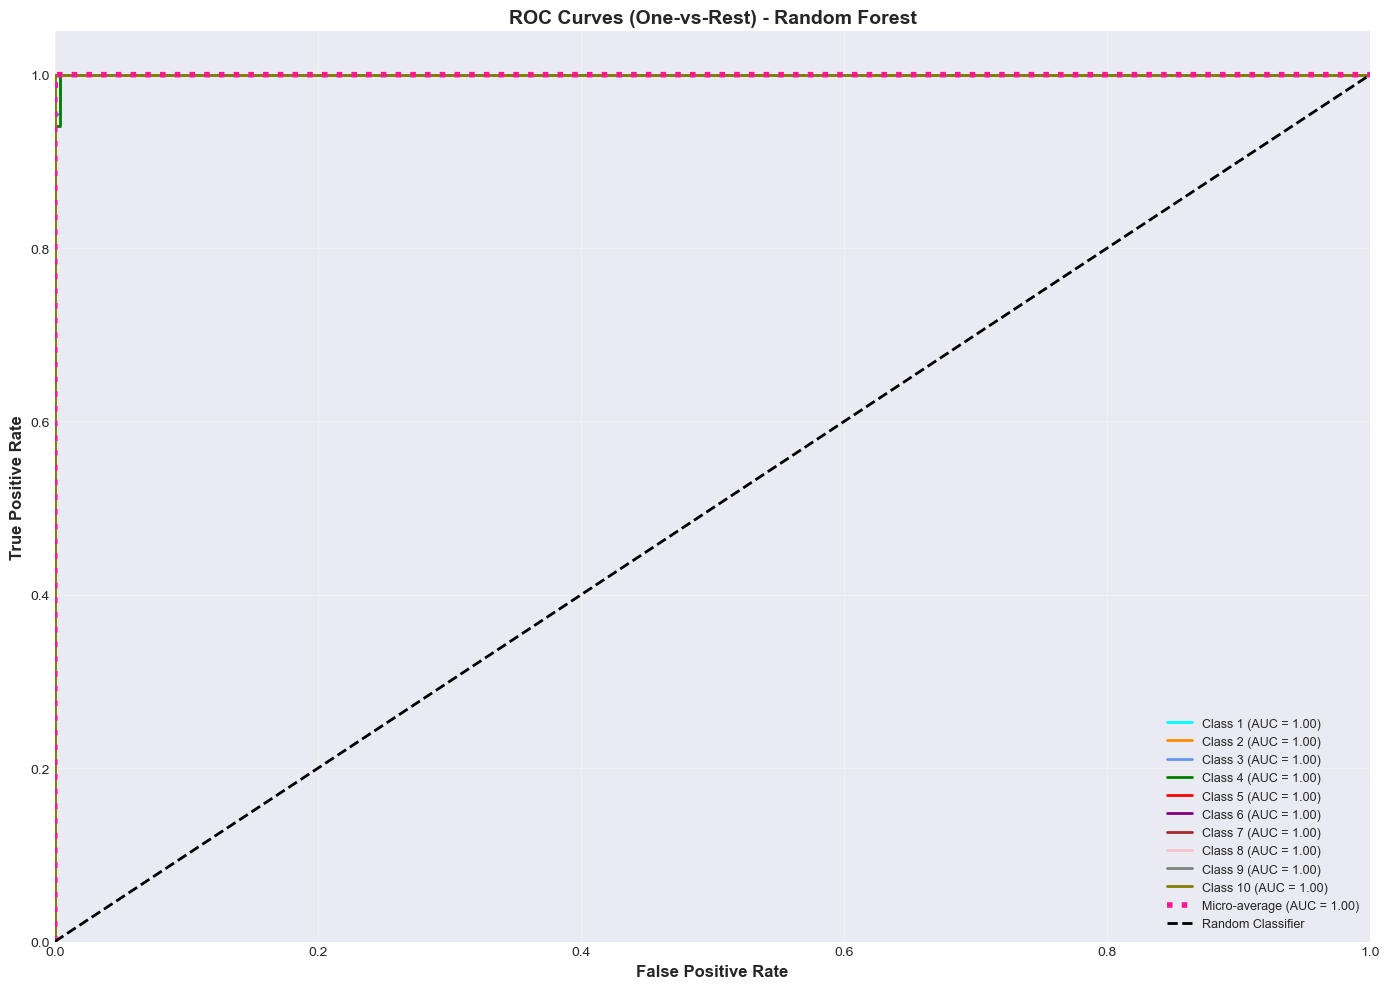

✓ ROC curves for Random Forest saved at:
C:\Users\Satyajit\Desktop\Real-Time-TGT\results\figures\model_performance\roc_curves\roc_curves_Random_Forest.png

AUC Scores for Random Forest:
   Class 1: 1.0000
   Class 2: 1.0000
   Class 3: 0.9998
   Class 4: 0.9998
   Class 5: 1.0000
   Class 6: 1.0000
   Class 7: 1.0000
   Class 8: 1.0000
   Class 9: 1.0000
   Class 10: 1.0000
   Micro-average: 1.0000

✓ ROC curve analysis completed


In [26]:
# CELL 24
# ============================================================================
print("ROC CURVES (ONE-VS-REST)")

import os
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Create ROC curve directory if not exists
os.makedirs(ROC_CURVES_DIR, exist_ok=True)

# Binarize labels for multi-class ROC
classes = sorted(y_train.unique())
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = len(classes)

print(f"\nGenerating ROC curves for {n_classes} classes...\n")

# Select best model
best_model = trained_models[best_model_name]

# Get probability / decision scores
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_selected)

elif hasattr(best_model, "decision_function"):
    y_score = best_model.decision_function(X_test_selected)

else:
    print(f"⚠ {best_model_name} does not support probability predictions")
    y_score = None


if y_score is not None:

    # If binary case returns 1D, convert to 2D
    if y_score.ndim == 1:
        y_score = y_score.reshape(-1, 1)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_test_binarized.ravel(),
        y_score.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curves
    plt.figure(figsize=(14, 10))

    colors = cycle([
        'aqua', 'darkorange', 'cornflowerblue', 'green', 'red',
        'purple', 'brown', 'pink', 'gray', 'olive'
    ])

    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})'
        )

    # Fixed line: label, not abel
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
        color='deeppink',
        linestyle=':',
        linewidth=4
    )

    plt.plot(
        [0, 1],
        [0, 1],
        'k--',
        lw=2,
        label='Random Classifier'
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(
        f'ROC Curves (One-vs-Rest) - {best_model_name}',
        fontsize=14,
        fontweight='bold'
    )

    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(
        ROC_CURVES_DIR,
        f'roc_curves_{best_model_name.replace(" ", "_")}.png'
    )

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ ROC curves for {best_model_name} saved at:")
    print(save_path)

    # Print AUC scores
    print(f"\nAUC Scores for {best_model_name}:")

    for i in range(n_classes):
        print(f"   Class {classes[i]}: {roc_auc[i]:.4f}")

    print(f"   Micro-average: {roc_auc['micro']:.4f}")

print("\n✓ ROC curve analysis completed")

In [27]:
# print("="*80)
# print("LEARNING CURVES")
# print("="*80)

# from sklearn.model_selection import learning_curve

# def plot_learning_curve(model, model_name, X, y, cv=5):
#     """
#     Generate and plot learning curve for a model.
#     """
#     train_sizes, train_scores, val_scores = learning_curve(
#         model, X, y, cv=cv, n_jobs=-1,
#         train_sizes=np.linspace(0.1, 1.0, 10),
#         scoring='accuracy',
#         random_state=RANDOM_STATE
#     )
    
#     train_mean = np.mean(train_scores, axis=1)
#     train_std = np.std(train_scores, axis=1)
#     val_mean = np.mean(val_scores, axis=1)
#     val_std = np.std(val_scores, axis=1)
    
#     return train_sizes, train_mean, train_std, val_mean, val_std

# # Generate learning curves for top 3 models
# top_3_models = eval_df.head(3)['Model'].tolist()

# print(f"\nGenerating learning curves for top 3 models: {', '.join(top_3_models)}\n")

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for idx, model_name in enumerate(top_3_models):
#     print(f"Computing learning curve for {model_name}...")
    
#     model = trained_models[model_name]
#     train_sizes, train_mean, train_std, val_mean, val_std = plot_learning_curve(
#         model, model_name, X_train_selected, y_train, cv=cv_folds
#     )
    
#     axes[idx].plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
#     axes[idx].plot(train_sizes, val_mean, 'o-', color='g', label='Validation Score')
    
#     axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
#                            alpha=0.1, color='r')
#     axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
#                            alpha=0.1, color='g')
    
#     axes[idx].set_xlabel('Training Examples', fontsize=11, fontweight='bold')
#     axes[idx].set_ylabel('Accuracy Score', fontsize=11, fontweight='bold')
#     axes[idx].set_title(f'Learning Curve\n{model_name}', fontsize=12, fontweight='bold')
#     axes[idx].legend(loc='best')
#     axes[idx].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(LEARNING_CURVES_DIR, 'learning_curves_top3_models.png'), dpi=300, bbox_inches='tight')
# plt.show()

# print("\n✓ Learning curves generated and saved")


LEARNING CURVES

Generating learning curves for top 3 models: Random Forest, Decision Tree, Logistic Regression

Computing learning curve for Random Forest...
Computing learning curve for Decision Tree...
Computing learning curve for Logistic Regression...


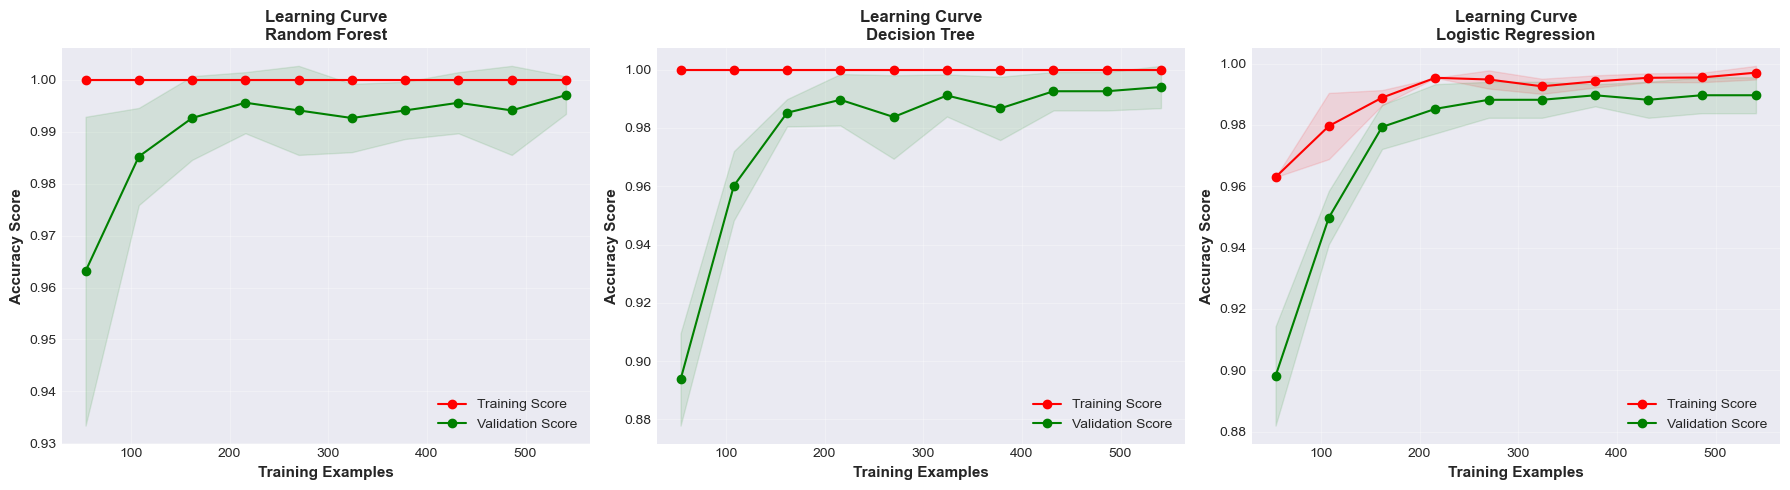


✓ Learning curves generated and saved


In [28]:
# ============================================================================
# CELL 25
# ============================================================================
print("="*80)
print("LEARNING CURVES")
print("="*80)
from sklearn.model_selection import learning_curve
def plot_learning_curve(model, model_name, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        random_state=RANDOM_STATE
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    return train_sizes, train_mean, train_std, val_mean, val_std
# Generate learning curves for top 3 models
top_3_models = eval_df.head(3)['Model'].tolist()
print(f"\nGenerating learning curves for top 3 models: {', '.join(top_3_models)}\n")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, model_name in enumerate(top_3_models):
    print(f"Computing learning curve for {model_name}...")
    model = trained_models[model_name]
    # IMPORTANT: Use y_train_model (0-indexed labels) instead of y_train
    train_sizes, train_mean, train_std, val_mean, val_std = plot_learning_curve(model, model_name, X_train_selected, y_train_model, cv=cv_folds)
    axes[idx].plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
    axes[idx].plot(train_sizes, val_mean, 'o-', color='g', label='Validation Score')
    axes[idx].fill_between(train_sizes, train_mean - train_std,train_mean + train_std, alpha=0.1, color='r')
    axes[idx].fill_between(train_sizes, val_mean - val_std,val_mean + val_std, alpha=0.1, color='g')
    axes[idx].set_xlabel('Training Examples', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Accuracy Score', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Learning Curve\n{model_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LEARNING_CURVES_DIR, 'learning_curves_top3_models.png'),dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Learning curves generated and saved")

In [29]:
# ============================================================================
# CELL 26
# ============================================================================
print("="*80)
print("FINAL MODEL SELECTION")
print("="*80)
# Select best model based on test accuracy and minimal overfitting
best_model_name = eval_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_test_acc = eval_df.iloc[0]['Test_Accuracy']
best_overfitting_gap = eval_df.iloc[0]['Overfitting_Gap']
print(f"\n🏆 Selected Best Model: {best_model_name}")
print(f"   Test Accuracy: {best_test_acc:.4f}")
print(f"   Overfitting Gap: {best_overfitting_gap:.4f}")
print(f"   Status: {'✓ Acceptable' if best_overfitting_gap <= 0.10 else '⚠ Needs attention'}")
# Save the best model
model_filename = f"best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
model_path = os.path.join(MODELS_DIR, model_filename)
joblib.dump(best_model, model_path)
print(f"\n✓ Best model saved to: {model_path}")
# Save model metadata
metadata = {
    'model_name': best_model_name,
    'test_accuracy': float(best_test_acc),
    'train_accuracy': float(eval_df.iloc[0]['Train_Accuracy']),
    'overfitting_gap': float(best_overfitting_gap),
    'precision': float(eval_df.iloc[0]['Precision']),
    'recall': float(eval_df.iloc[0]['Recall']),
    'f1_score': float(eval_df.iloc[0]['F1_Score']),
    'training_time': float(eval_df.iloc[0]['Training_Time']),
    'selected_features': top_features,
    'n_features': len(top_features),
    'n_classes': int(n_classes),
    'classes': [int(c) for c in classes],
    'cv_mean_accuracy': float(cv_df[cv_df['Model'] == best_model_name]['CV_Mean_Accuracy'].values[0]),
    'cv_std': float(cv_df[cv_df['Model'] == best_model_name]['CV_Std'].values[0]),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
metadata_path = os.path.join(MODELS_DIR, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✓ Model metadata saved to: {metadata_path}")
# Save all trained models
all_models_path = os.path.join(MODELS_DIR, 'all_trained_models.pkl')
joblib.dump(trained_models, all_models_path)
print(f"✓ All trained models saved to: {all_models_path}")
print("\n✓ Model saving completed!")

FINAL MODEL SELECTION

🏆 Selected Best Model: Random Forest
   Test Accuracy: 0.9966
   Overfitting Gap: 0.0034
   Status: ✓ Acceptable

✓ Best model saved to: C:\Users\Satyajit\Desktop\Real-Time-TGT\models\best_model_random_forest.pkl
✓ Model metadata saved to: C:\Users\Satyajit\Desktop\Real-Time-TGT\models\model_metadata.json
✓ All trained models saved to: C:\Users\Satyajit\Desktop\Real-Time-TGT\models\all_trained_models.pkl

✓ Model saving completed!


In [30]:
# ============================================================================
# CELL 27
# ============================================================================
print("="*80)
print("GENERATING FINAL SUMMARY REPORT")
print("="*80)
# Create comprehensive summary report
summary_report = f"""
{'='*80}
AIRCRAFT TARGET CLASSIFICATION PROJECT - FINAL REPORT
{'='*80}
PROJECT DETAILS:
--------------
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Random Seed: {RANDOM_STATE}
DATASET INFORMATION:
------------------
Total Samples: {len(df_final_features)}
Original Features: {len(feature_names)}
Selected Features: {len(top_features)}
Number of Classes: {n_classes}
Classes: {classes}
Train-Test Split: {100-CONFIG['test_size']*100:.0f}%-{CONFIG['test_size']*100:.0f}%
Training Samples: {len(X_train)}
Test Samples: {len(X_test)}
FEATURE SELECTION:
----------------
Method: Consensus Ranking (ANOVA + Mutual Info + Random Forest + XGBoost)
Top {n_top_features} Selected Features:
"""
for i, feat in enumerate(top_features, 1):
    summary_report += f"{i:2d}. {feat}\n"
summary_report += f"""
MODEL TRAINING RESULTS:
---------------------
Number of Models Trained: {len(models)}
Cross-Validation Folds: {cv_folds}
Model Performance Summary (sorted by Test Accuracy):
"""
for _, row in eval_df.iterrows():
    summary_report += f"""
{row['Model']}:
   Train Accuracy: {row['Train_Accuracy']:.4f}
   Test Accuracy:  {row['Test_Accuracy']:.4f}
   Precision:      {row['Precision']:.4f}
   Recall:         {row['Recall']:.4f}
   F1-Score:       {row['F1_Score']:.4f}
   Overfitting:    {row['Overfitting_Gap']:.4f}
   Training Time:  {row['Training_Time']:.2f}s
"""
summary_report += f"""
BEST MODEL:
----------
Model: {best_model_name}
Test Accuracy: {best_test_acc:.4f}
Cross-Validation Mean: {metadata['cv_mean_accuracy']:.4f} (±{metadata['cv_std']:.4f})
Overfitting Gap: {best_overfitting_gap:.4f}
Status: {'Acceptable - No significant overfitting' if best_overfitting_gap <= 0.10 else 'Warning - Potential overfitting detected'}
FILES GENERATED:
--------------
- Best Model: {model_filename}
- Scaler: scaler.pkl
- Model Metadata: model_metadata.json
- Feature Rankings: feature_rankings.csv
- Model Comparison: model_comparison.csv
- Cross-Validation Results: cross_validation_results.csv
VISUALIZATIONS GENERATED:
-----------------------
EDA Figures: {len([f for f in os.listdir(EDA_FIGURES_DIR) if f.endswith('.png')])} files
Feature Selection Figures: {len([f for f in os.listdir(FEATURE_SEL_FIGURES_DIR) if f.endswith('.png')])} files
Model Performance Figures: {len([f for f in os.listdir(MODEL_PERF_FIGURES_DIR) if f.endswith('.png')])} files
Confusion Matrices: {len([f for f in os.listdir(CONFUSION_MAT_DIR) if f.endswith('.png')])} files
ROC Curves: {len([f for f in os.listdir(ROC_CURVES_DIR) if f.endswith('.png')])} files
Learning Curves: {len([f for f in os.listdir(LEARNING_CURVES_DIR) if f.endswith('.png')])} files
{'='*80}
END OF REPORT
{'='*80}
"""
# Print summary report
print(summary_report)
# Save summary report
summary_path = os.path.join(REPORTS_DIR, 'final_summary_report.txt')
with open(summary_path, 'w') as f:
    f.write(summary_report)
print(f"\n✓ Final summary report saved to: {summary_path}")
print("\n✓✓✓ PROJECT TRAINING PHASE COMPLETED SUCCESSFULLY! ✓✓✓")

GENERATING FINAL SUMMARY REPORT

AIRCRAFT TARGET CLASSIFICATION PROJECT - FINAL REPORT
PROJECT DETAILS:
--------------
Generated: 2026-05-03 15:32:31
Random Seed: 42
DATASET INFORMATION:
------------------
Total Samples: 968
Original Features: 32
Selected Features: 15
Number of Classes: 10
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Train-Test Split: 70%-30%
Training Samples: 677
Test Samples: 291
FEATURE SELECTION:
----------------
Method: Consensus Ranking (ANOVA + Mutual Info + Random Forest + XGBoost)
Top 15 Selected Features:
 1. Height_rate_std
 2. Resultant_acceleration_range
 3. AGC_min
 4. AGC_max
 5. Resultant_velocity_range
 6. AGC_mean
 7. Resultant_acceleration_rate_std
 8. Resultant_velocity_std
 9. Resultant_velocity_rate_mean
10. Resultant_velocity_rate_std
11. Height_mean
12. Resultant_acceleration_std
13. Height_std
14. Resultant_acceleration_max
15. Resultant_velocity_max